In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from scipy.stats import chi2_contingency
import prince  # Bibliothèque pour ACM / MCA, faire pip install --upgrade prince scikit-learn pandas numpy si nécessaire

In [ ]:
# Charger le jeu de données depuis le dossier data
chemin_fichier = "../data/td_clustering_karafun.csv"
data = pd.read_csv(chemin_fichier)

# Structure y dimension
print(data.info())
print("Lignes et colonnes :", data.shape)

# Valeurs nulles
print(data.isnull().sum())

# Valeurs dupliquées
print("Valeurs dupliquées :", data.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 341092 entries, 0 to 341091
Data columns (total 16 columns):
 #   Column                      Non-Null Count   Dtype 
---  ------                      --------------   ----- 
 0   id_anonyme                  341092 non-null  object
 1   anciennete_client_tr        341092 non-null  object
 2   anciennete_abonnement_tr    341092 non-null  object
 3   statut_abonnement           341092 non-null  object
 4   type_client                 341092 non-null  object
 5   type_very_first_abo         341092 non-null  object
 6   type_first_abo_last_streak  341092 non-null  object
 7   ratio_fidelite_tr           341092 non-null  object
 8   methode_paiement            341092 non-null  object
 9   nb_abo_periode              341092 non-null  int64 
 10  valeur_12M_tr               341092 non-null  object
 11  avg_sessions_actifs_tr      341092 non-null  object
 12  avg_songs_sessions_tr       341092 non-null  object
 13  utilise_remote              3

In [ ]:
cat_cols = ['statut_abonnement', 'methode_paiement', 'zone_geo', 
            'contactable', 'valeur_12M_tr', 'avg_sessions_actifs_tr']

for col in cat_cols:
    print(f"--- Distribution de {col} ---")
    print(data[col].value_counts(dropna=False))
    print(data) # Pourcentage
    print("\n")

--- Distribution de statut_abonnement ---
statut_abonnement
non_actif    171486
actif        169606
Name: count, dtype: int64
                                               id_anonyme  \
0       fbb58c58395ab62899c58d6a52f8159ca12ddd7f46bfe2...   
1       8c981dbb88db4abcfd1c07b30ec42c370195fabaf74b8a...   
2       a4b6c3d31fb413aa830dbb423bd3d8446438dae71d9973...   
3       ef9a45455295911d59cd8a9c76d32d582709e40a5a238f...   
4       91d37bd372c738eddb00a6b2878877161fb26a2a519bf8...   
...                                                   ...   
341087  307bb032a30fd0efc547dd099c9e4031a745cbe3006f7e...   
341088  0b635881062c3ef7b85588efc92fe5e57d080c527ab4c0...   
341089  6d010310bed61b708217e2b9b6fa551127c04268d68110...   
341090  f99daa136ac76e181d2c4e2fc222088fe782b60918449d...   
341091  a64b4ae3ba5fc0a9326422a8ee01aff77442e699005126...   

       anciennete_client_tr anciennete_abonnement_tr statut_abonnement  \
0           00_moins_1_mois          00_moins_1_mois             ac

In [ ]:
# Stats desc générales
print(data[['nb_abo_periode']].describe())

# Mode et Médiane
print("Médiane:", data['nb_abo_periode'].median())
print("Mode:", data['nb_abo_periode'].mode()[0])

       nb_abo_periode
count   341092.000000
mean         5.454860
std          4.356785
min          1.000000
25%          1.000000
50%          4.000000
75%         10.000000
max         12.000000
Médiane: 4.0
Mode: 1


C:\Users\SebastianAraya\AppData\Local\Temp\ipykernel_16340\4264730040.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=col, order=order, palette="viridis")


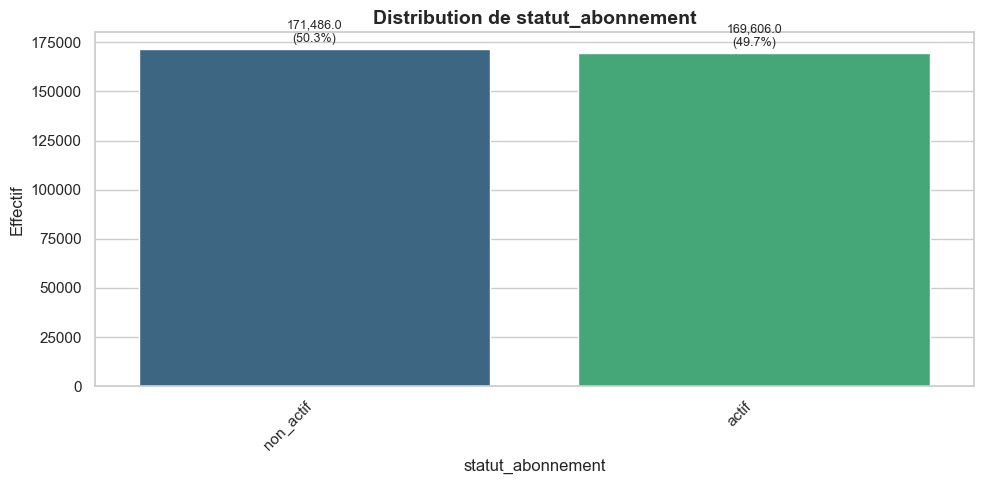

C:\Users\SebastianAraya\AppData\Local\Temp\ipykernel_16340\4264730040.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=col, order=order, palette="viridis")


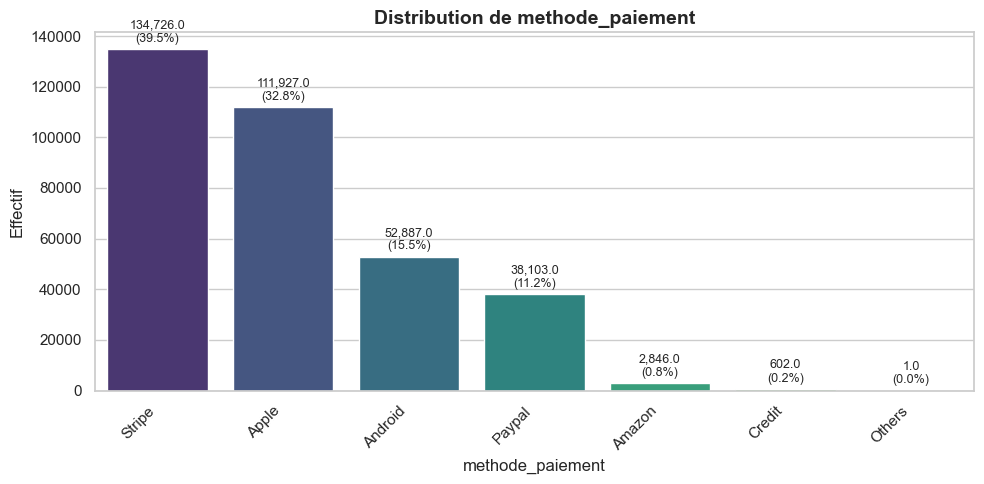

C:\Users\SebastianAraya\AppData\Local\Temp\ipykernel_16340\4264730040.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=col, order=order, palette="viridis")


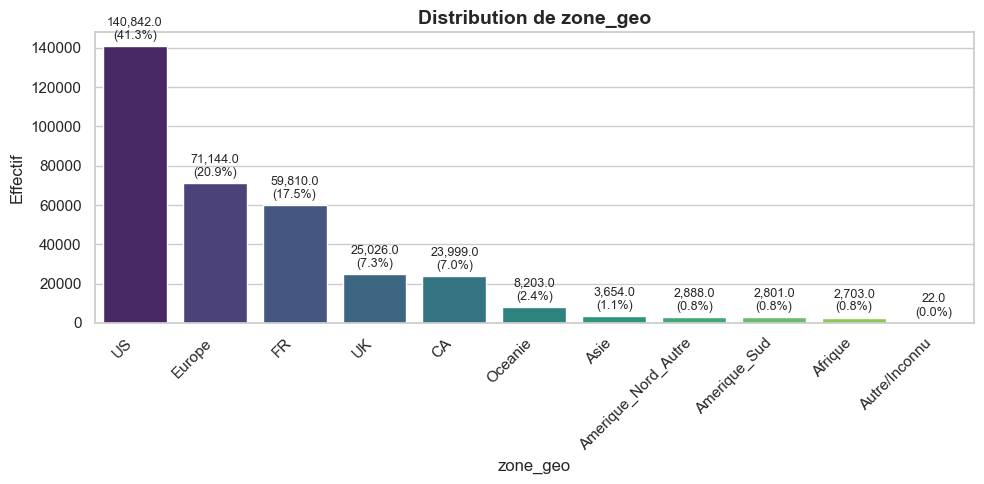

C:\Users\SebastianAraya\AppData\Local\Temp\ipykernel_16340\4264730040.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=col, order=order, palette="viridis")


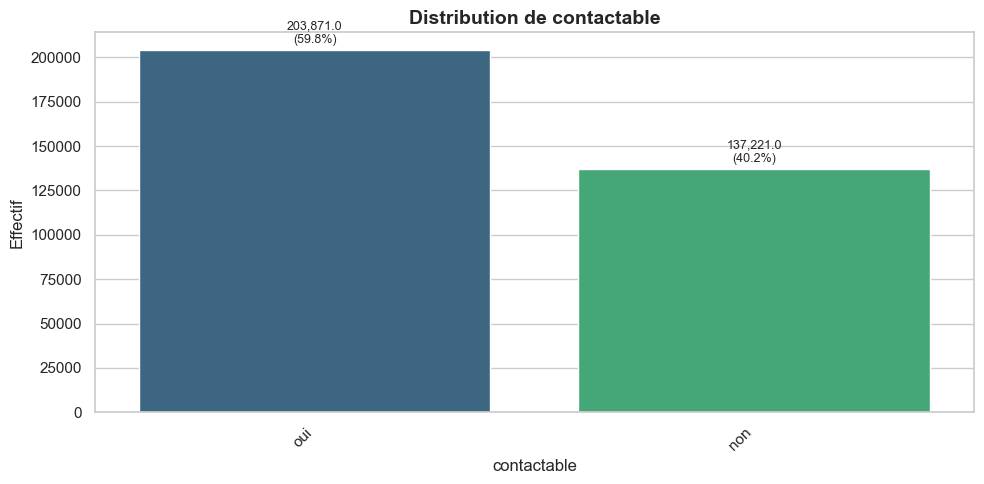

C:\Users\SebastianAraya\AppData\Local\Temp\ipykernel_16340\4264730040.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=col, order=order, palette="viridis")


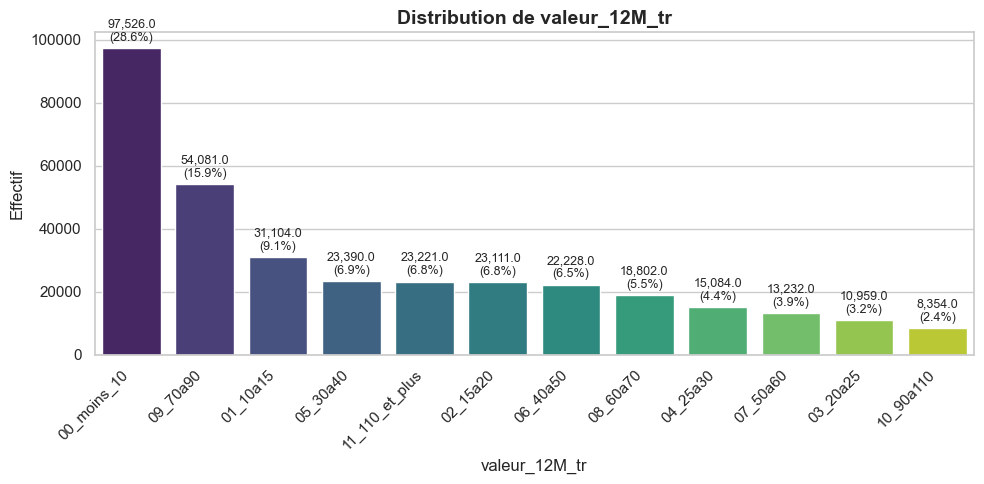

C:\Users\SebastianAraya\AppData\Local\Temp\ipykernel_16340\4264730040.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.countplot(data=data, x=col, order=order, palette="viridis")


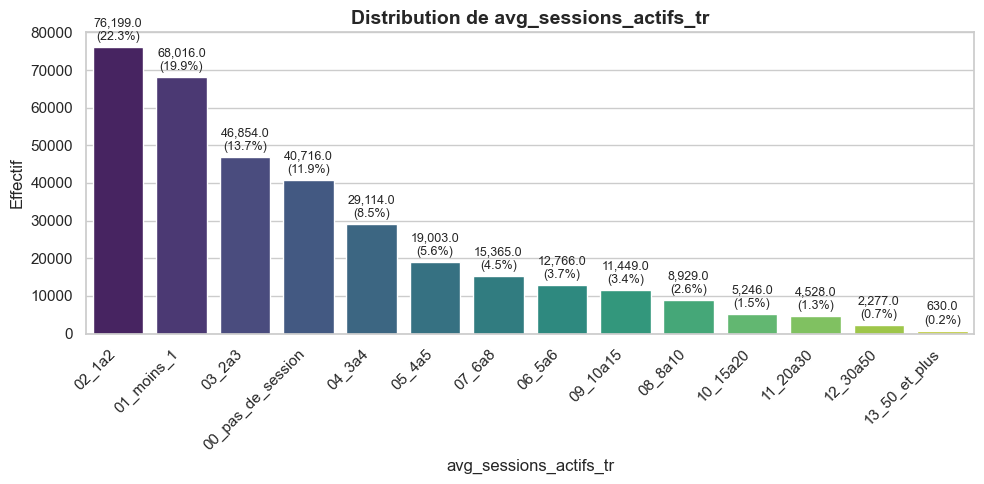

In [ ]:
# Configuration du style des graphiques
sns.set_theme(style="whitegrid")

# Graphiques de distribution pour chaque variable catégorielle
for col in cat_cols:
    plt.figure(figsize=(10, 5))
    
    # Calcul des fréquences pour ordonner les barres
    order = data[col].value_counts().index
    
    # Création du barplot
    ax = sns.countplot(data=data, x=col, order=order, palette="viridis")
    
    # Ajout des pourcentages au-dessus de chaque barre
    total = len(data[col])
    for p in ax.patches:
        height = p.get_height()
        percentage = f'{100 * height / total:.1f}%'
        ax.annotate(f'{height:,}\n({percentage})', 
                    (p.get_x() + p.get_width() / 2., height),
                    ha='center', va='bottom', fontsize=9, xytext=(0, 3),
                    textcoords='offset points')
        
    plt.title(f"Distribution de {col}", fontsize=14, fontweight='bold')
    plt.xlabel(col, fontsize=12)
    plt.ylabel("Effectif", fontsize=12)
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

In [ ]:
# Génération d'une table de fréquences pour chaque variable
tables_frequences = {}

for col in cat_cols:
    # Calcul des fréquences absolues et relatives
    counts = data[col].value_counts(dropna=False)
    percentages = data[col].value_counts(normalize=True, dropna=False) * 100
    
    # Création du DataFrame récapitulatif
    df_freq = pd.DataFrame({
        'Modalité': counts.index,
        'Effectif': counts.values,
        'Pourcentage (%)': percentages.values.round(2)
    })
    
    tables_frequences[col] = df_freq
    
    print(f"=== Table de fréquence : {col} ===")
    print(df_freq.to_string(index=False))
    print("\n" + "="*40 + "\n")

=== Table de fréquence : statut_abonnement ===
 Modalité  Effectif  Pourcentage (%)
non_actif    171486            50.28
    actif    169606            49.72


=== Table de fréquence : methode_paiement ===
Modalité  Effectif  Pourcentage (%)
  Stripe    134726            39.50
   Apple    111927            32.81
 Android     52887            15.51
  Paypal     38103            11.17
  Amazon      2846             0.83
  Credit       602             0.18
  Others         1             0.00


=== Table de fréquence : zone_geo ===
           Modalité  Effectif  Pourcentage (%)
                 US    140842            41.29
             Europe     71144            20.86
                 FR     59810            17.53
                 UK     25026             7.34
                 CA     23999             7.04
            Oceanie      8203             2.40
               Asie      3654             1.07
Amerique_Nord_Autre      2888             0.85
       Amerique_Sud      2801             0

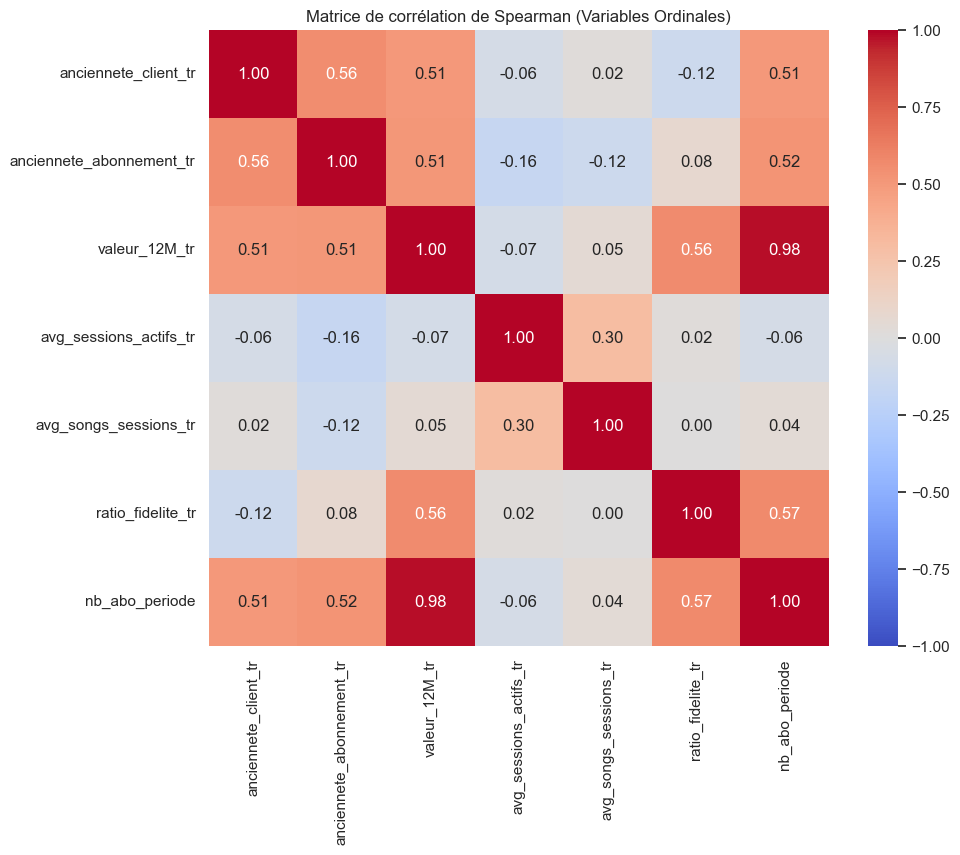

In [ ]:
# Variables ordinales et discretes
cols_ordinales = [
    'anciennete_client_tr', 'anciennete_abonnement_tr', 
    'valeur_12M_tr', 'avg_sessions_actifs_tr', 
    'avg_songs_sessions_tr', 'ratio_fidelite_tr'
]

df_corr = data[cols_ordinales + ['nb_abo_periode']].copy()

for col in cols_ordinales:
    df_corr[col] = df_corr[col].astype('category').cat.codes

# Matrice
corr_matrix = df_corr.corr(method='spearman')

# 4. Visualization
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Matrice de corrélation de Spearman (Variables Ordinales)")
plt.show()

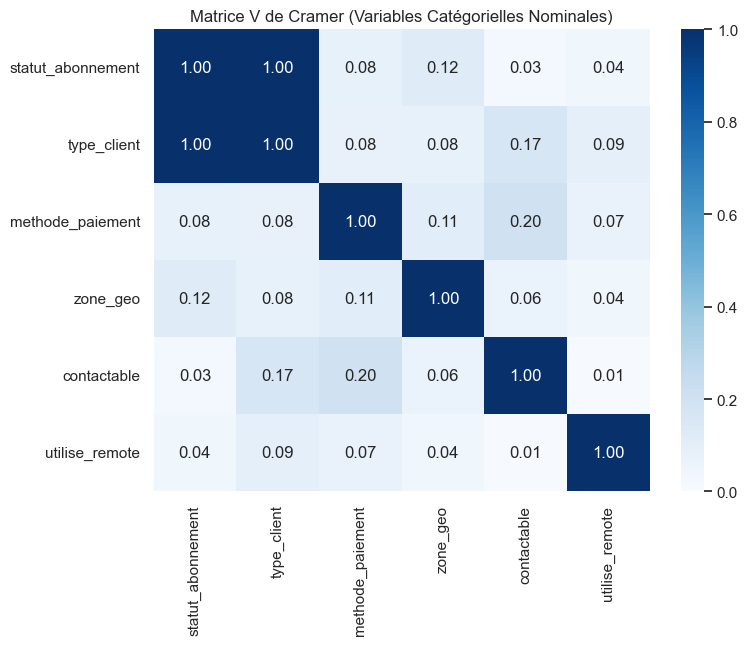

In [ ]:
def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)
    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()
    phi2 = chi2 / n
    r, k = confusion_matrix.shape
    phi2corr = max(0, phi2 - ((k-1)*(r-1))/(n-1))
    rcorr = r - ((r-1)**2)/(n-1)
    kcorr = k - ((k-1)**2)/(n-1)
    if min((kcorr-1), (rcorr-1)) == 0:
        return 0.0
    return np.sqrt(phi2corr / min((kcorr-1), (rcorr-1)))

# Colonnes catégorielles nominales
cols_nominales = ['statut_abonnement', 'type_client', 'methode_paiement', 'zone_geo', 'contactable', 'utilise_remote']

# Matrice V de Cramer
v_matrix = pd.DataFrame(index=cols_nominales, columns=cols_nominales, dtype=float)

for col1 in cols_nominales:
    for col2 in cols_nominales:
        v_matrix.loc[col1, col2] = cramers_v(data[col1], data[col2])

# Visualization
plt.figure(figsize=(8, 6))
sns.heatmap(v_matrix, annot=True, cmap='Blues', vmin=0, vmax=1, fmt=".2f")
plt.title("Matrice V de Cramer (Variables Catégorielles Nominales)")
plt.show()

C:\Users\SebastianAraya\AppData\Local\Temp\ipykernel_16340\3789934901.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_globale.index, y=dist_globale.values, palette='Blues_d')


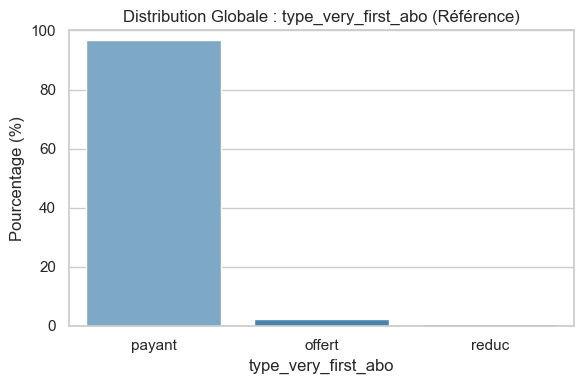

c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppD

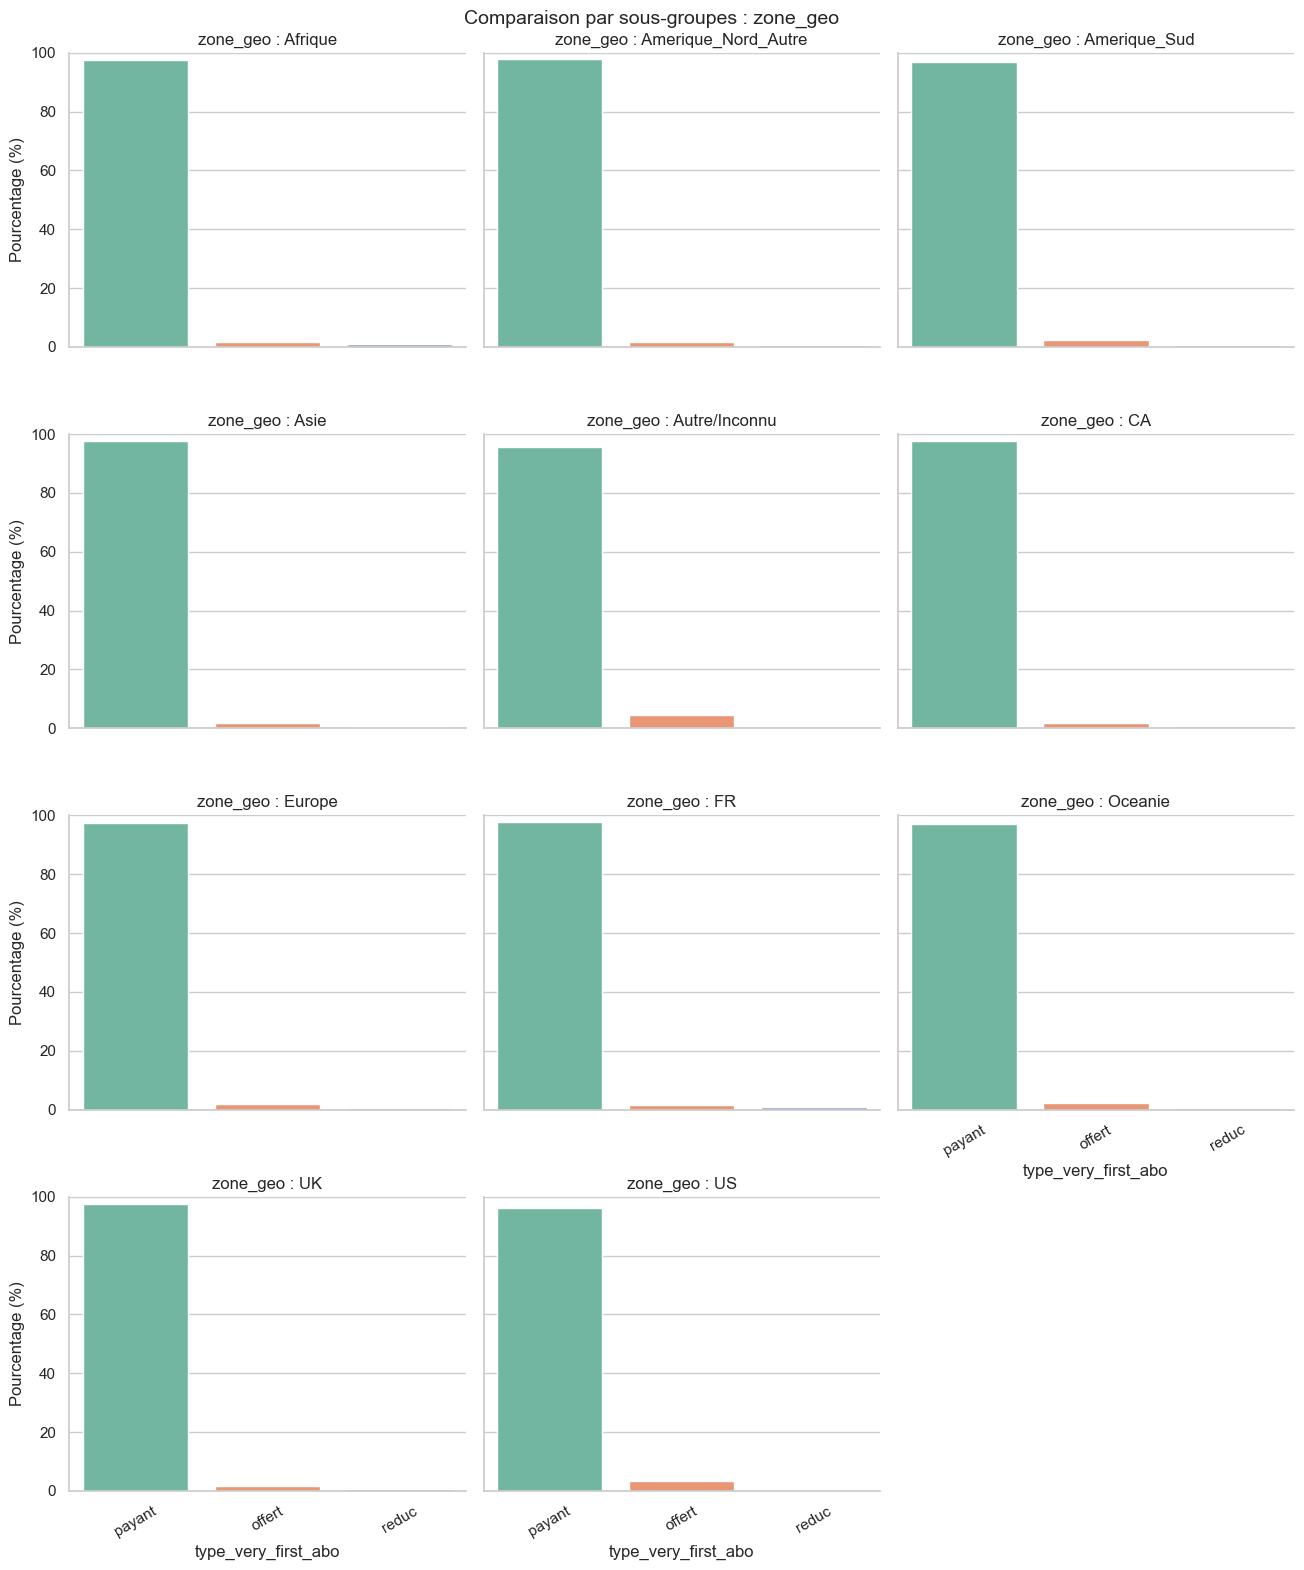

c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppD

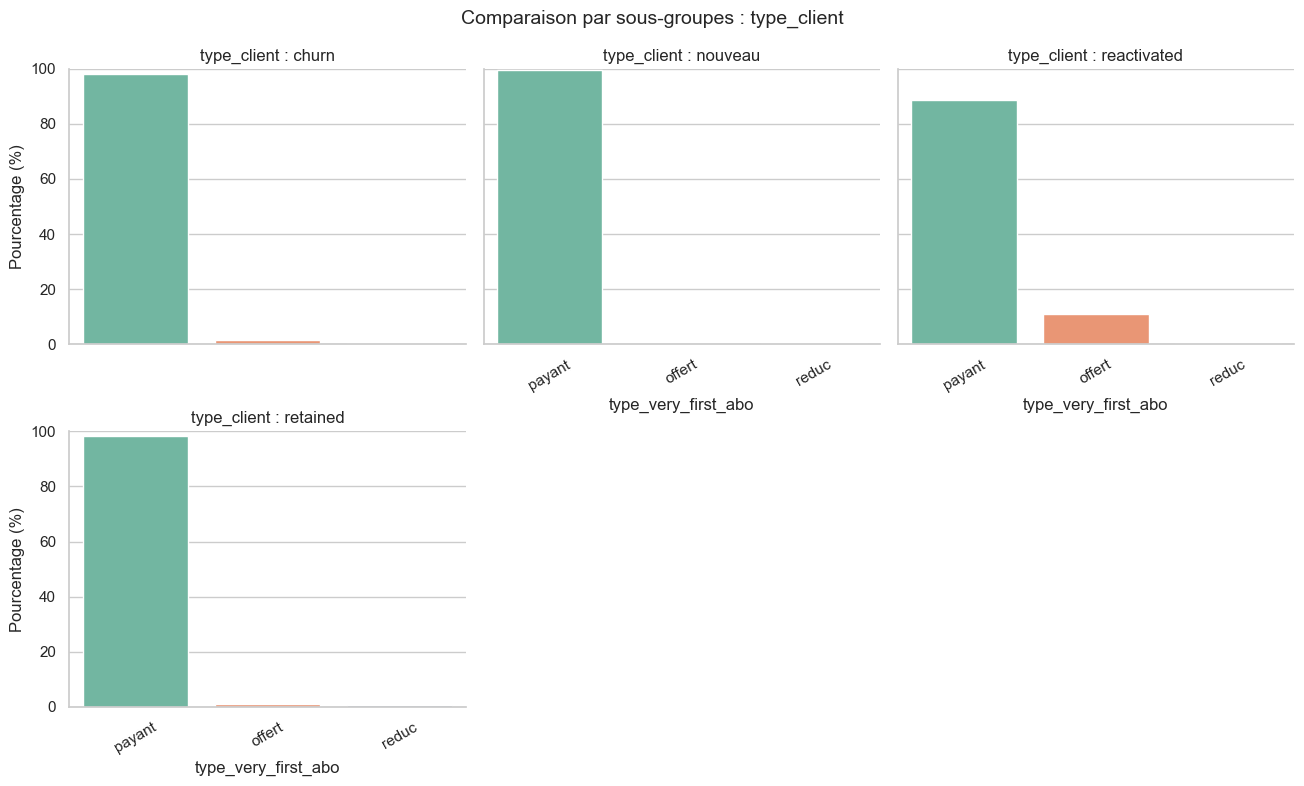

c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppD

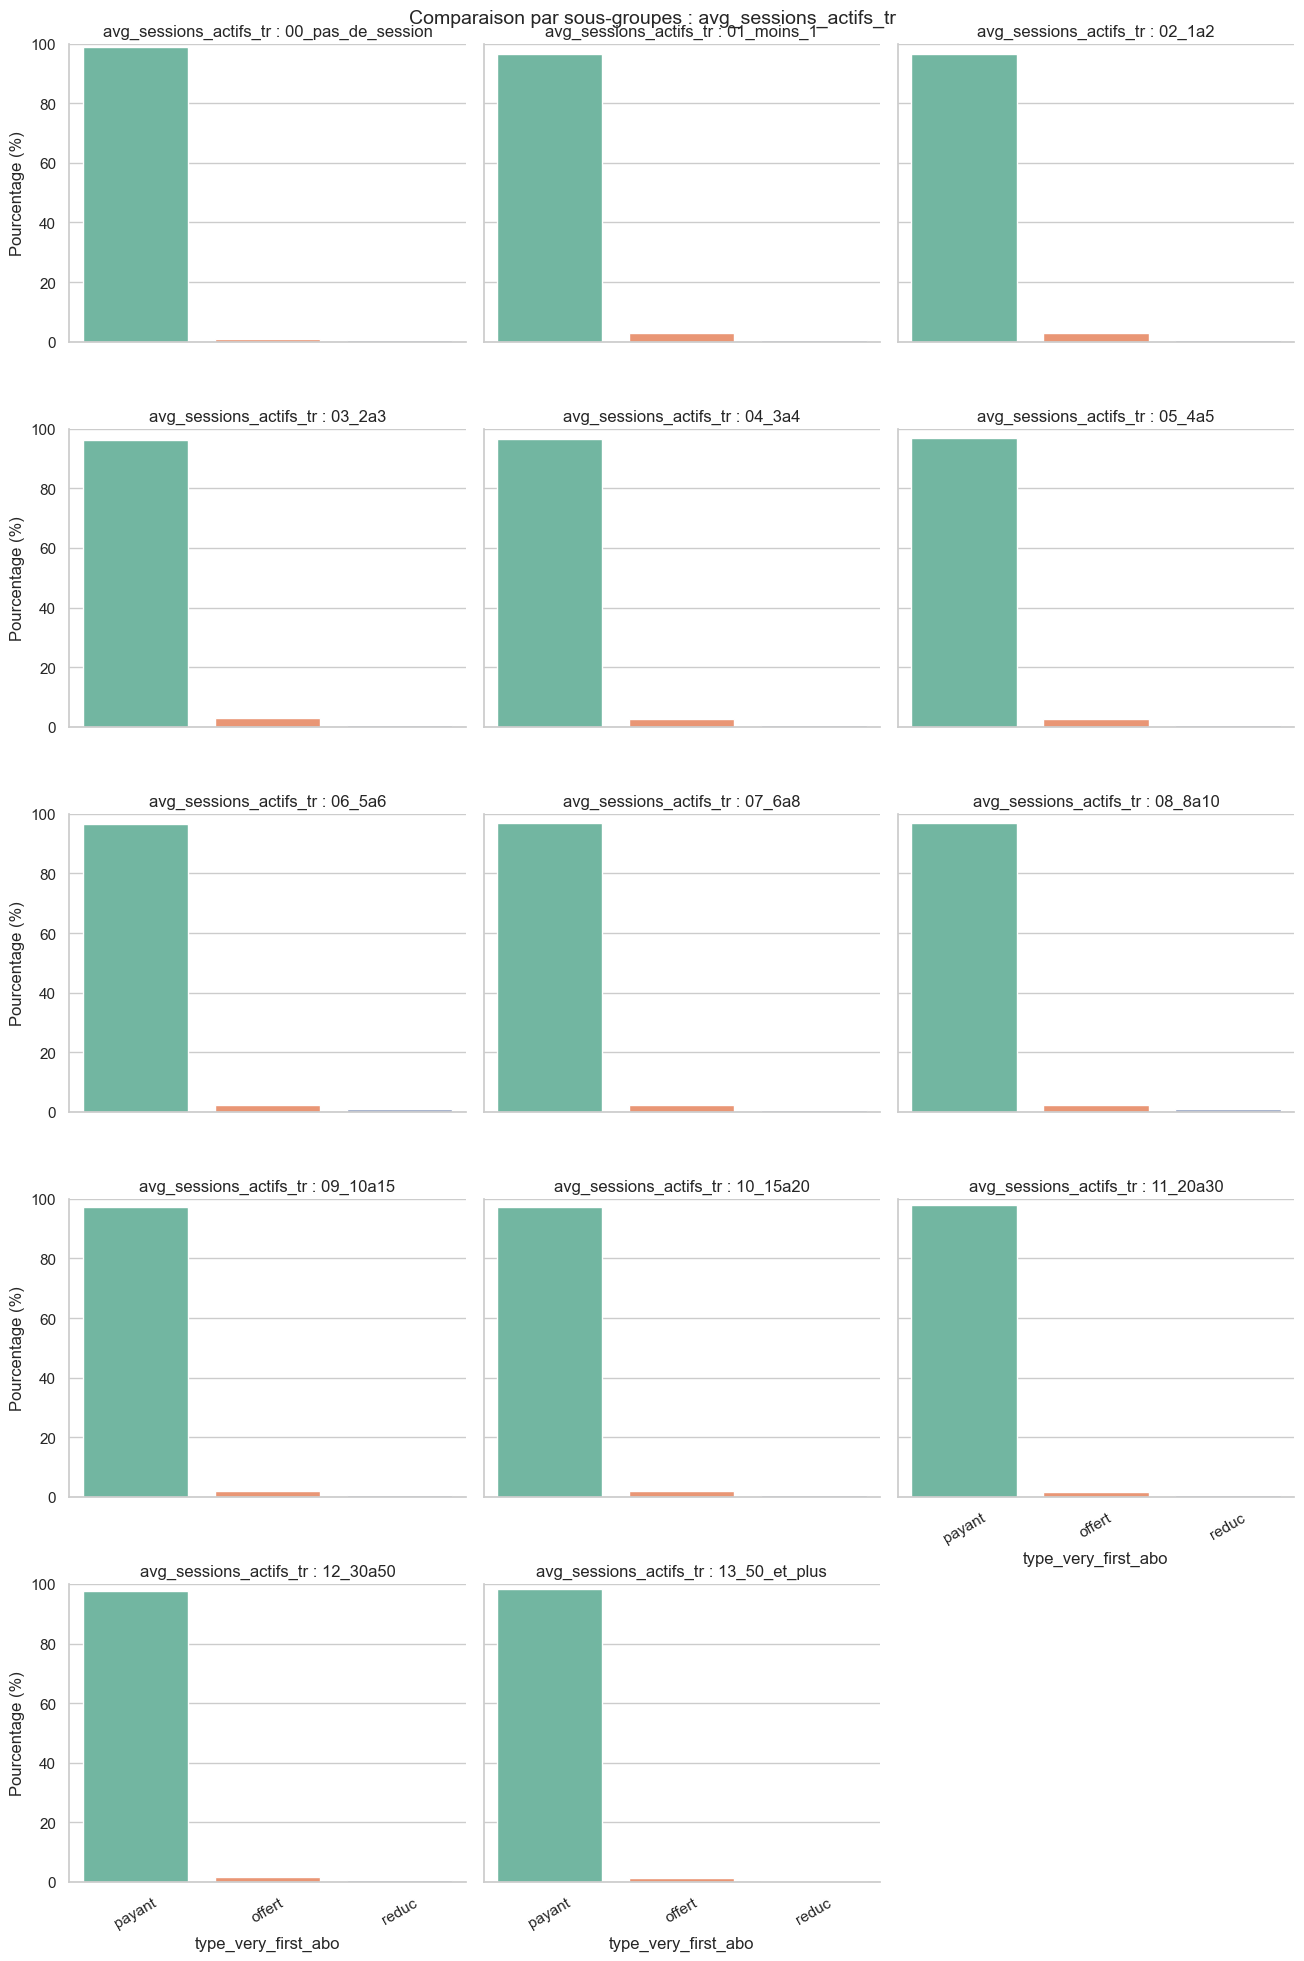

In [ ]:
# 1. Calcul de la distribution globale de référence (type_very_first_abo)
dist_globale = data['type_very_first_abo'].value_counts(normalize=True) * 100

# Affichage du graphique de référence
plt.figure(figsize=(6, 4))
sns.barplot(x=dist_globale.index, y=dist_globale.values, palette='Blues_d')
plt.title('Distribution Globale : type_very_first_abo (Référence)')
plt.ylabel('Pourcentage (%)')
plt.xlabel('type_very_first_abo')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# 2. Liste des variables à analyser
liste_variables = ['zone_geo', 'type_client', 'avg_sessions_actifs_tr']

# 3. Boucle d'itération sur chaque variable
for var in liste_variables:
    # Calcul des proportions relatives pour la variable actuelle
    df_prop = (
        data.groupby(var)['type_very_first_abo']
        .value_counts(normalize=True)
        .rename('pourcentage')
        .reset_index()
    )
    df_prop['pourcentage'] *= 100
    
    # Création de la grille de sous-graphiques (FacetGrid)
    # col_wrap=3 permet d'afficher 3 graphiques par ligne au maximum
    g = sns.FacetGrid(df_prop, col=var, col_wrap=3, height=4, aspect=1.1)
    g.map_dataframe(sns.barplot, x='type_very_first_abo', y='pourcentage', palette='Set2')
    
    # Personnalisation visuelle de la grille
    g.set_axis_labels('type_very_first_abo', 'Pourcentage (%)')
    g.set_titles(col_template=f'{var} : {{col_name}}')
    g.set(ylim=(0, 100))  # Maintien de l'échelle fixe à 100%
    
    # Rotation des étiquettes si le texte sur l'axe X est trop long
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=30)
        
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f'Comparaison par sous-groupes : {var}', fontsize=14)
    plt.tight_layout()
    plt.show()

C:\Users\SebastianAraya\AppData\Local\Temp\ipykernel_16340\4200297218.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dist_globale_paiement.index, y=dist_globale_paiement.values, palette='Blues_d')


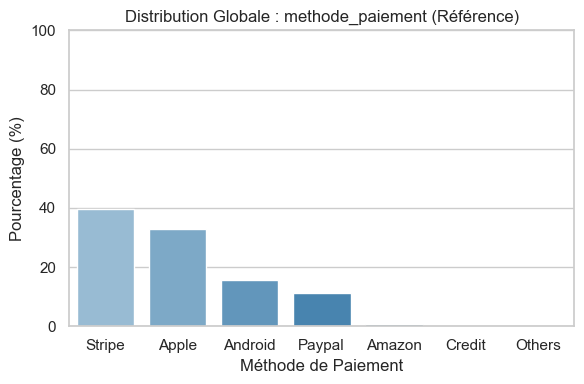

c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppD

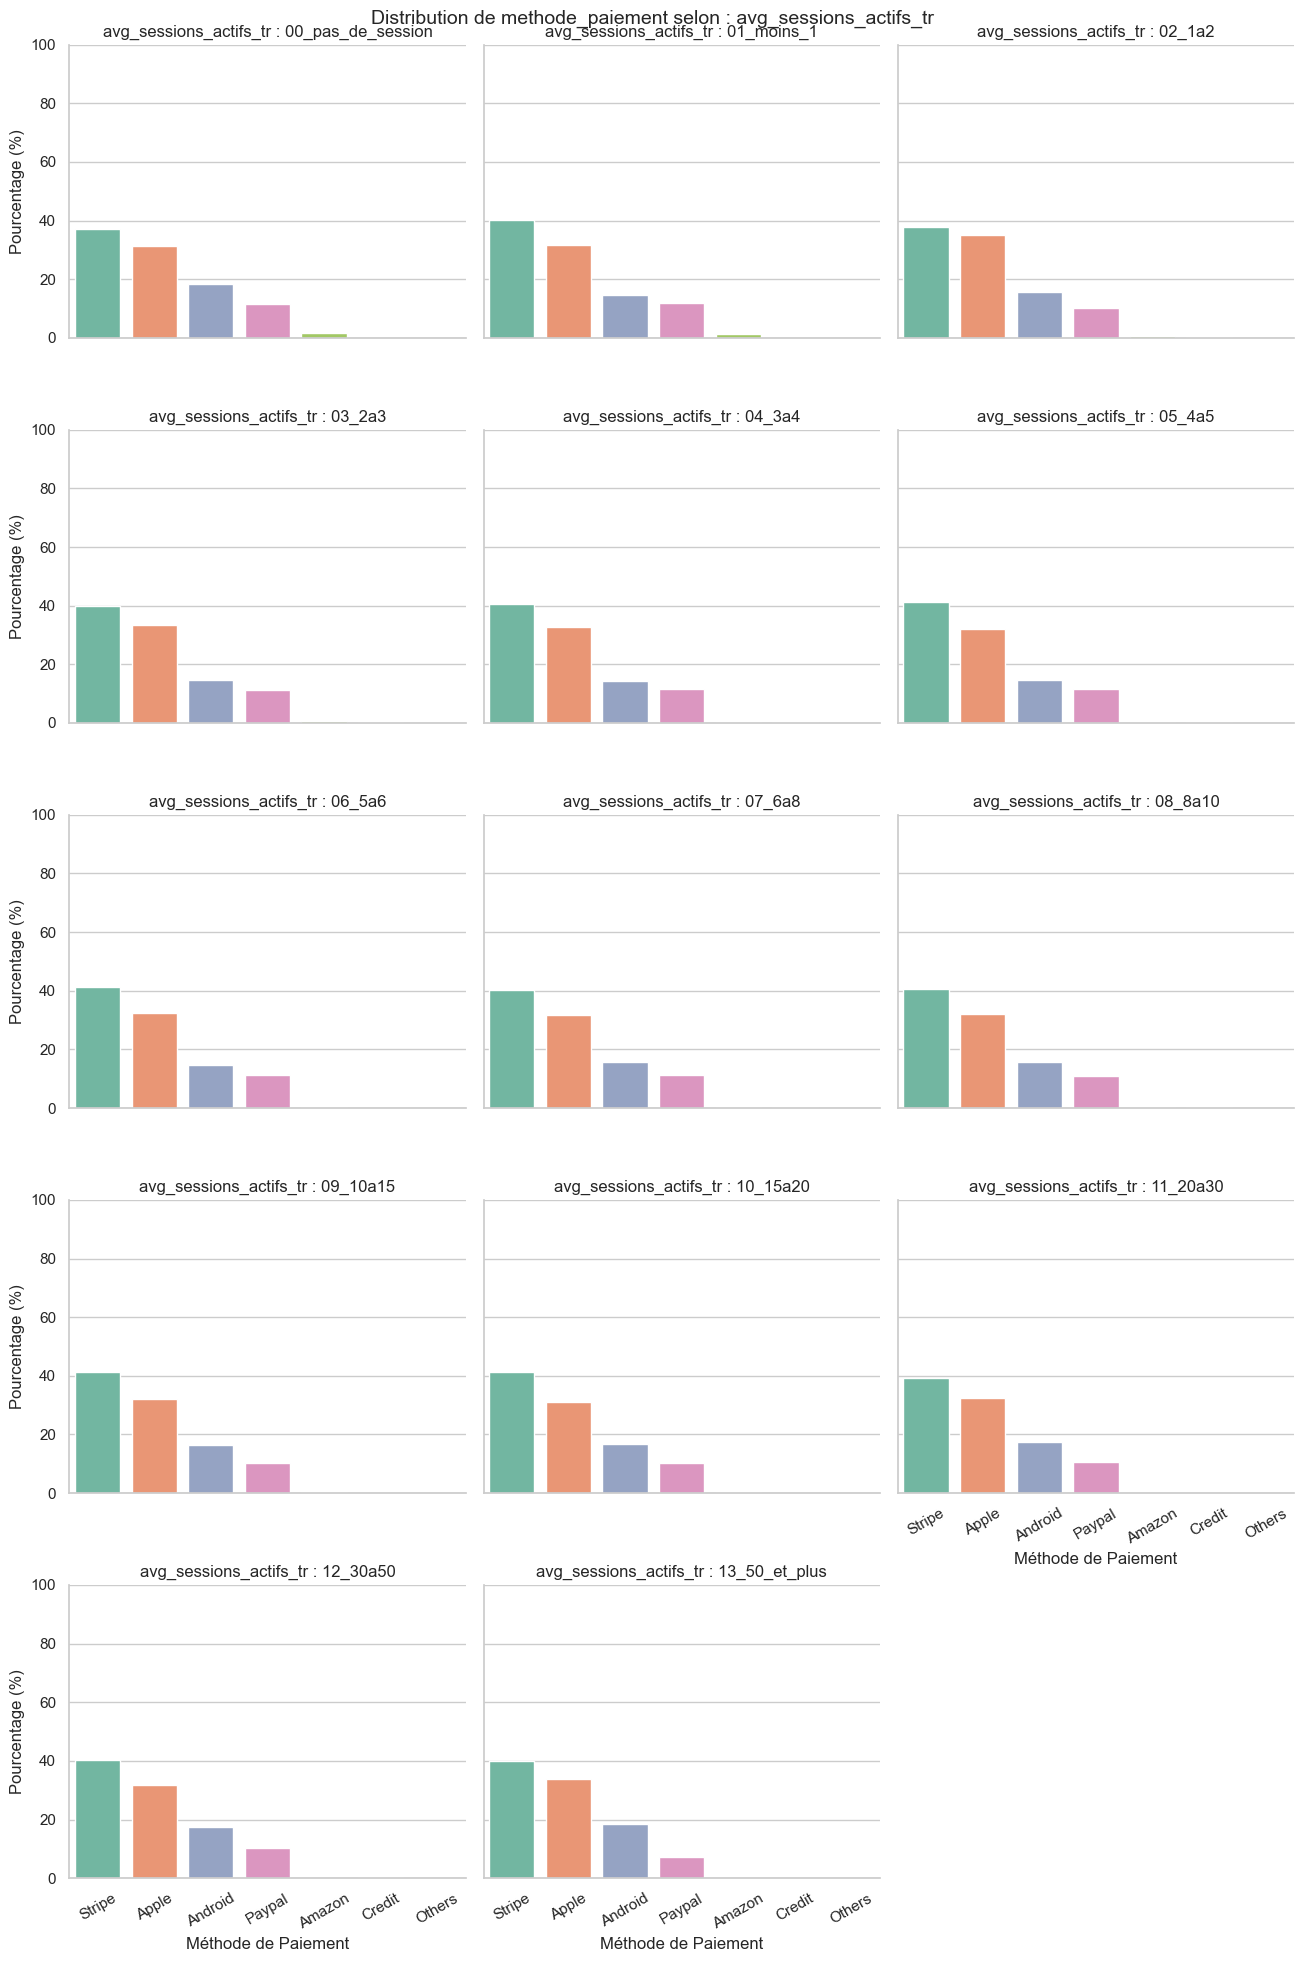

c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppD

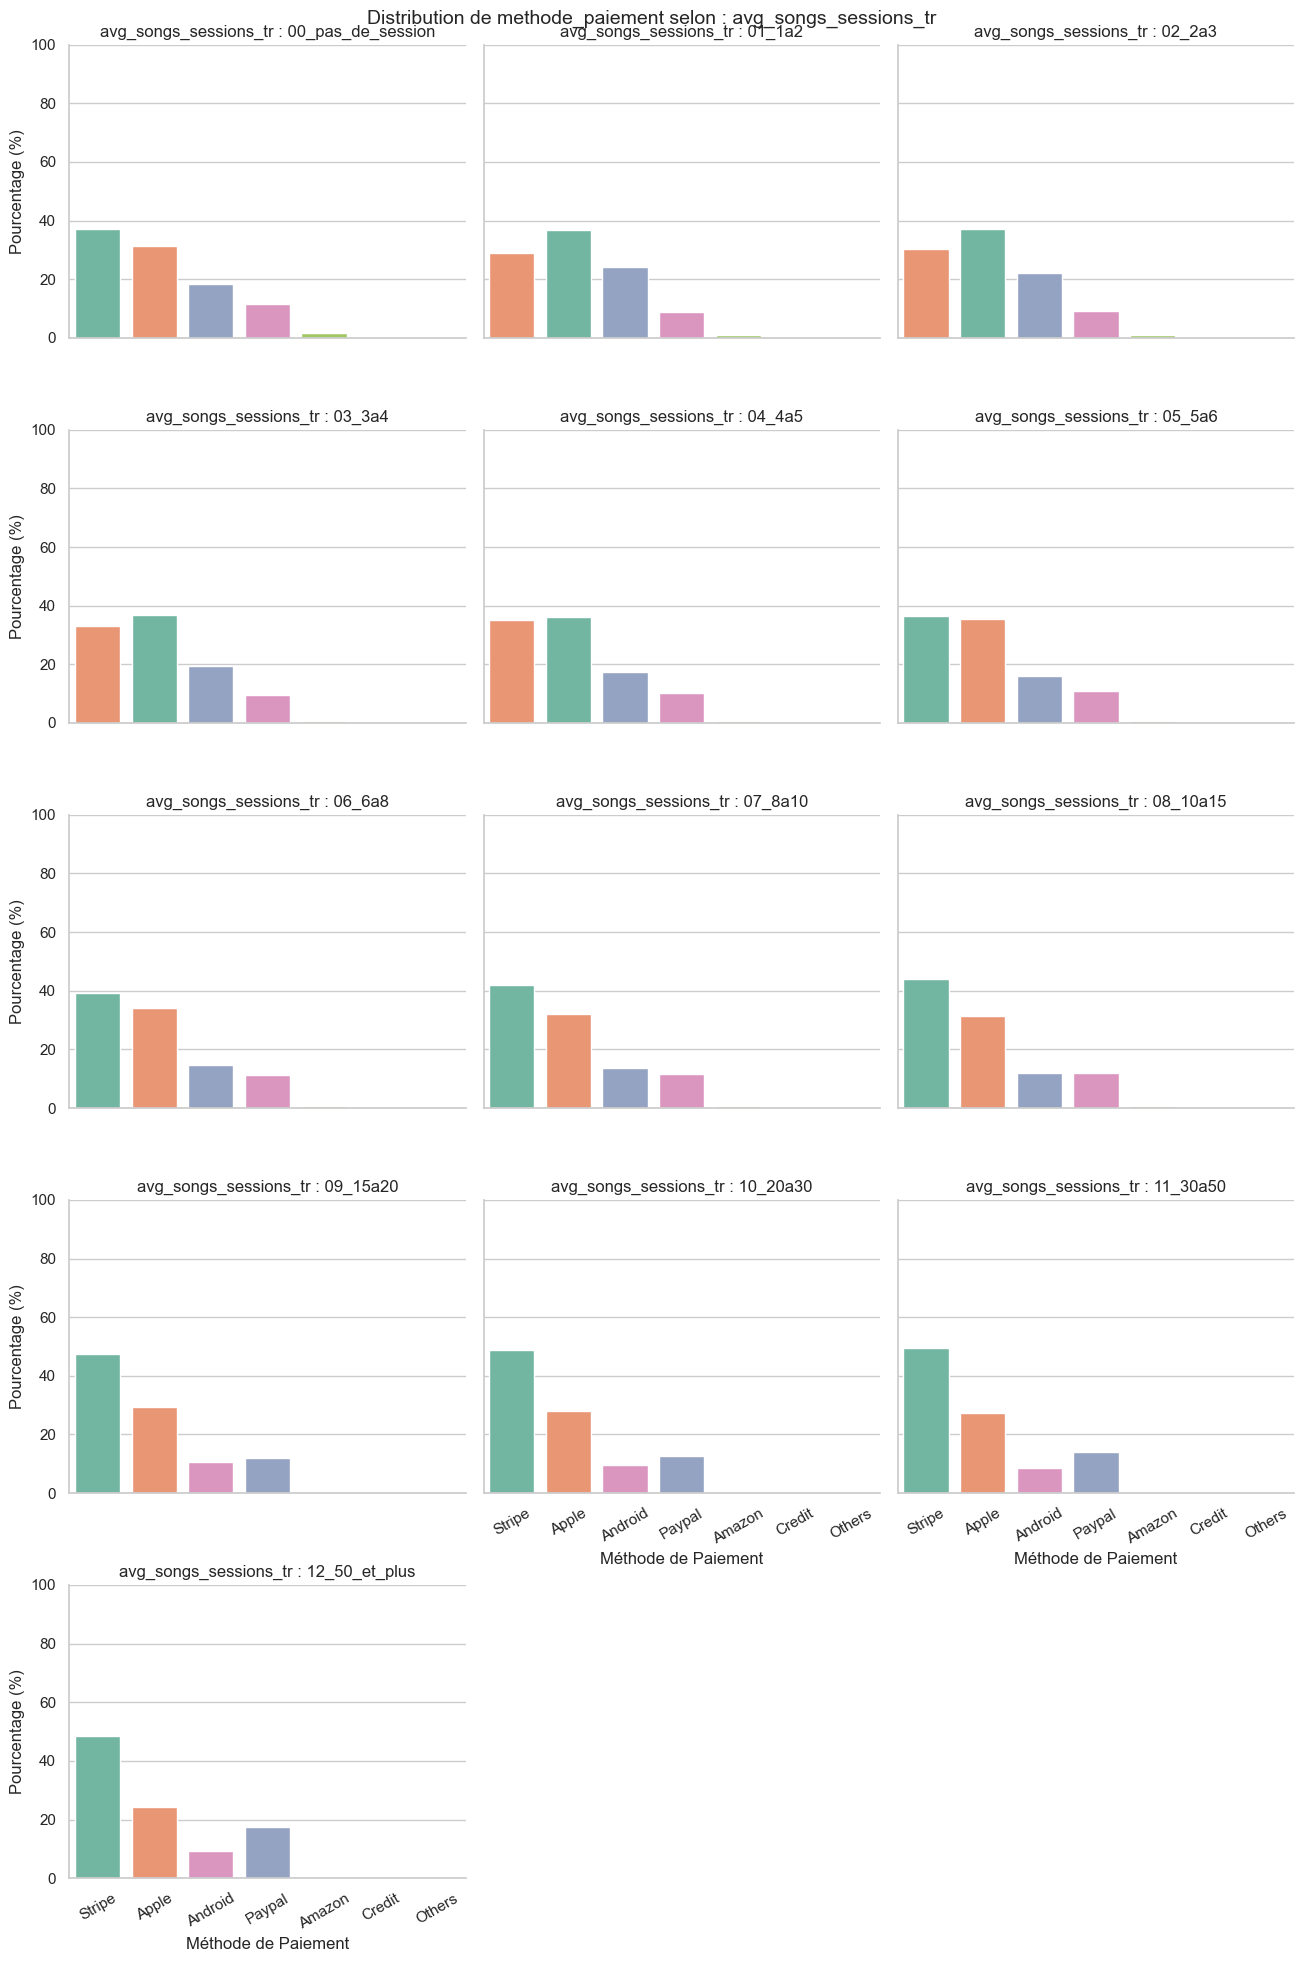

c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppD

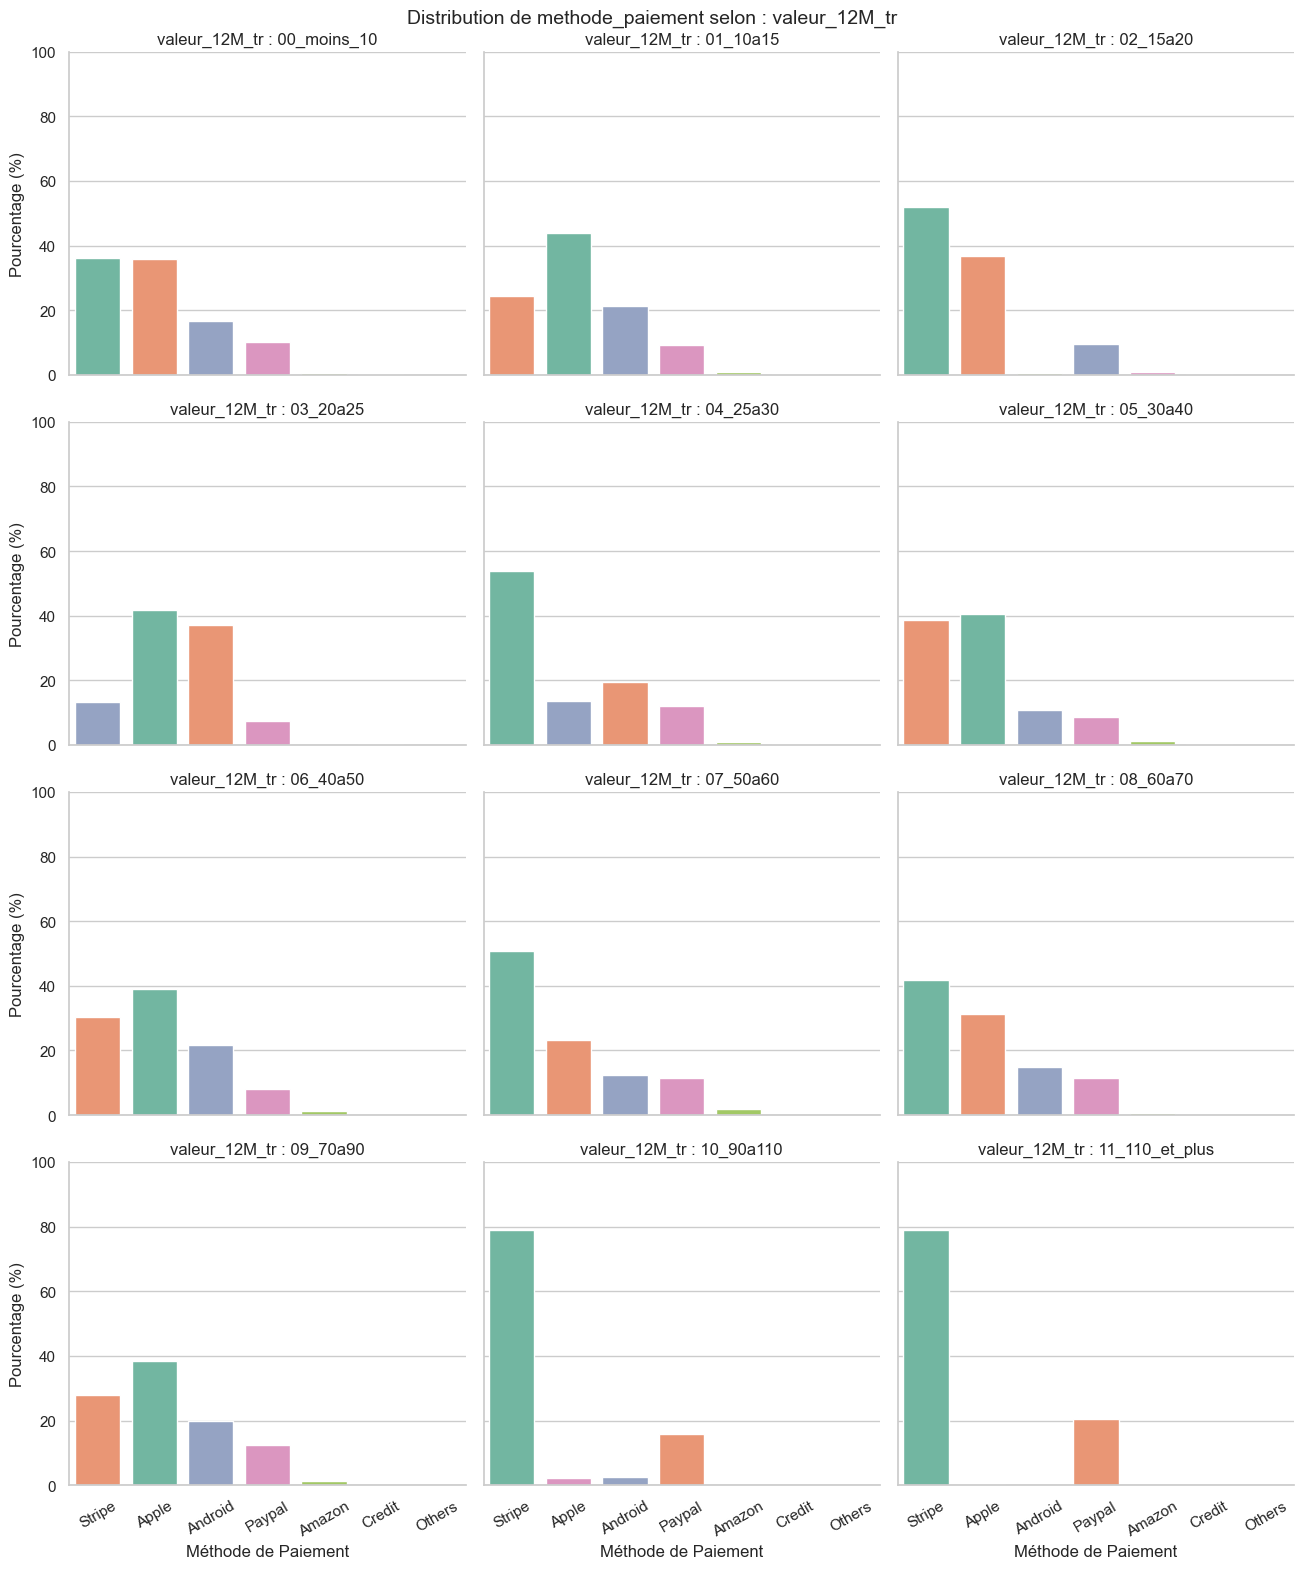

c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)


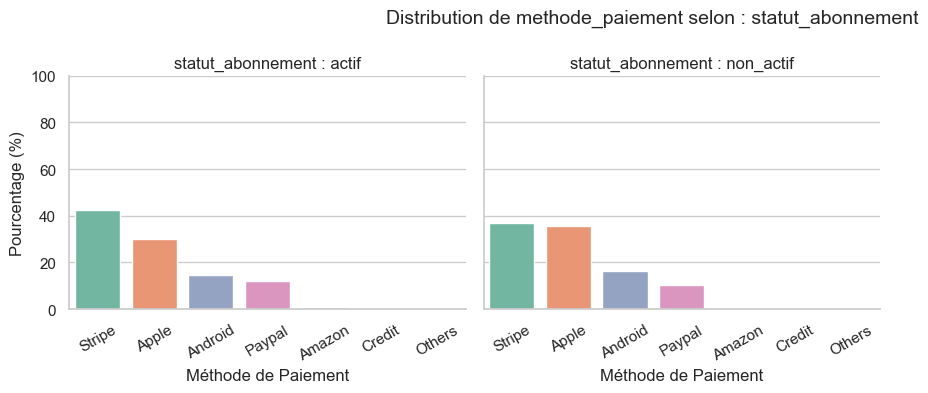

c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppD

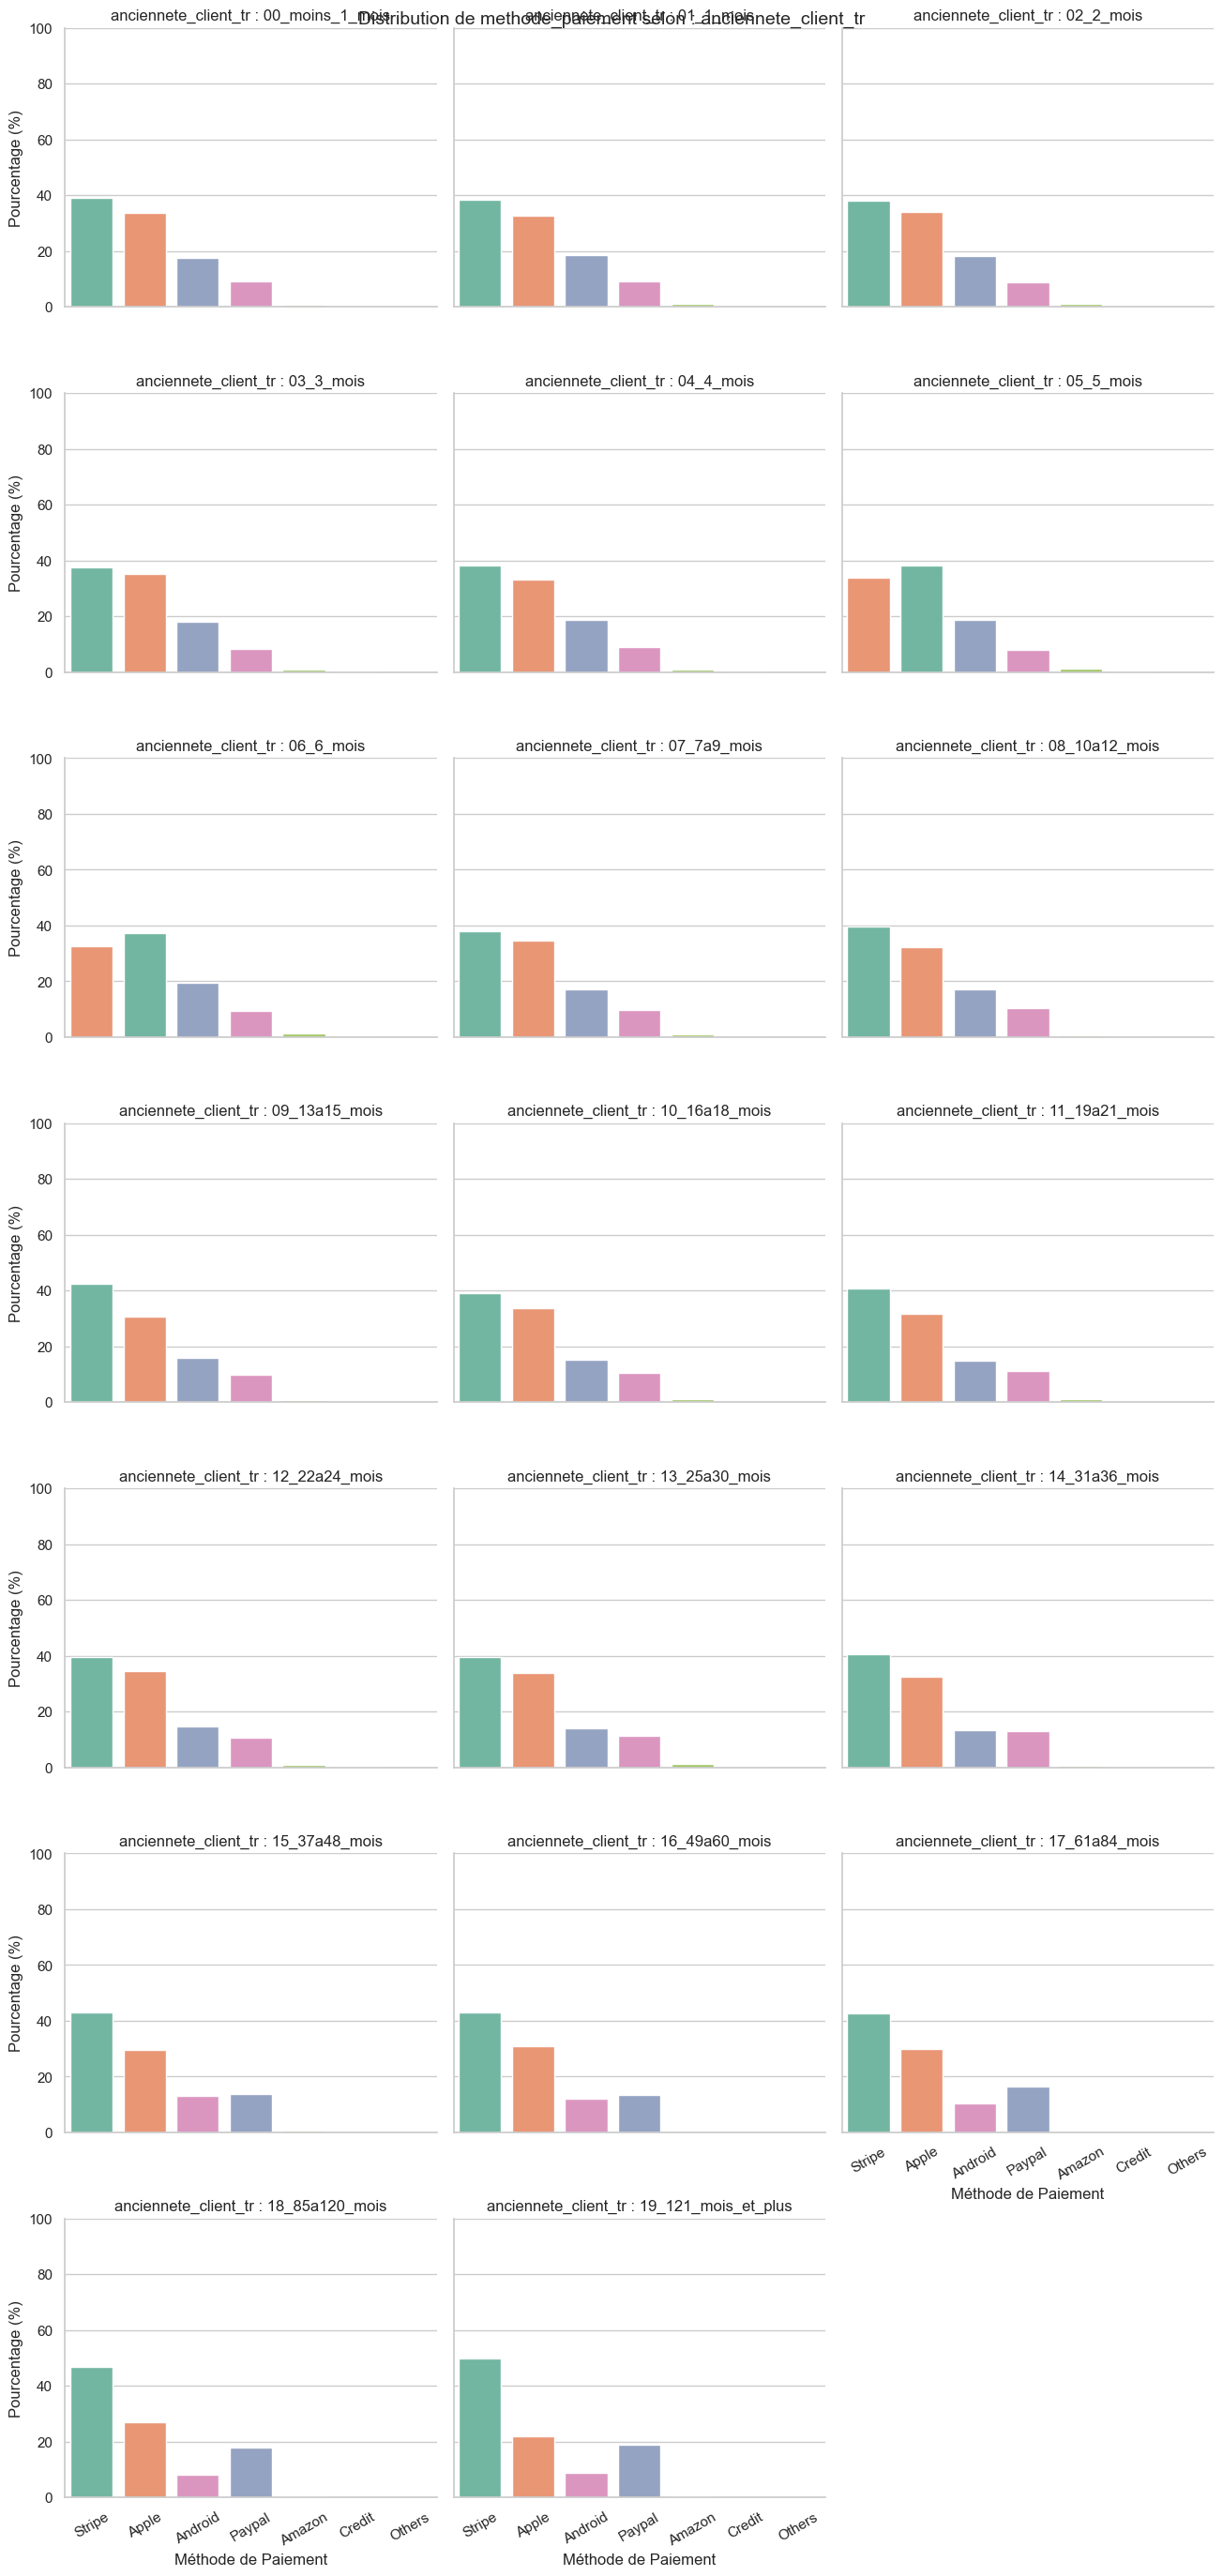

c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppData\Local\Programs\Python\Python311\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  func(*plot_args, **plot_kwargs)
c:\Users\SebastianAraya\AppD

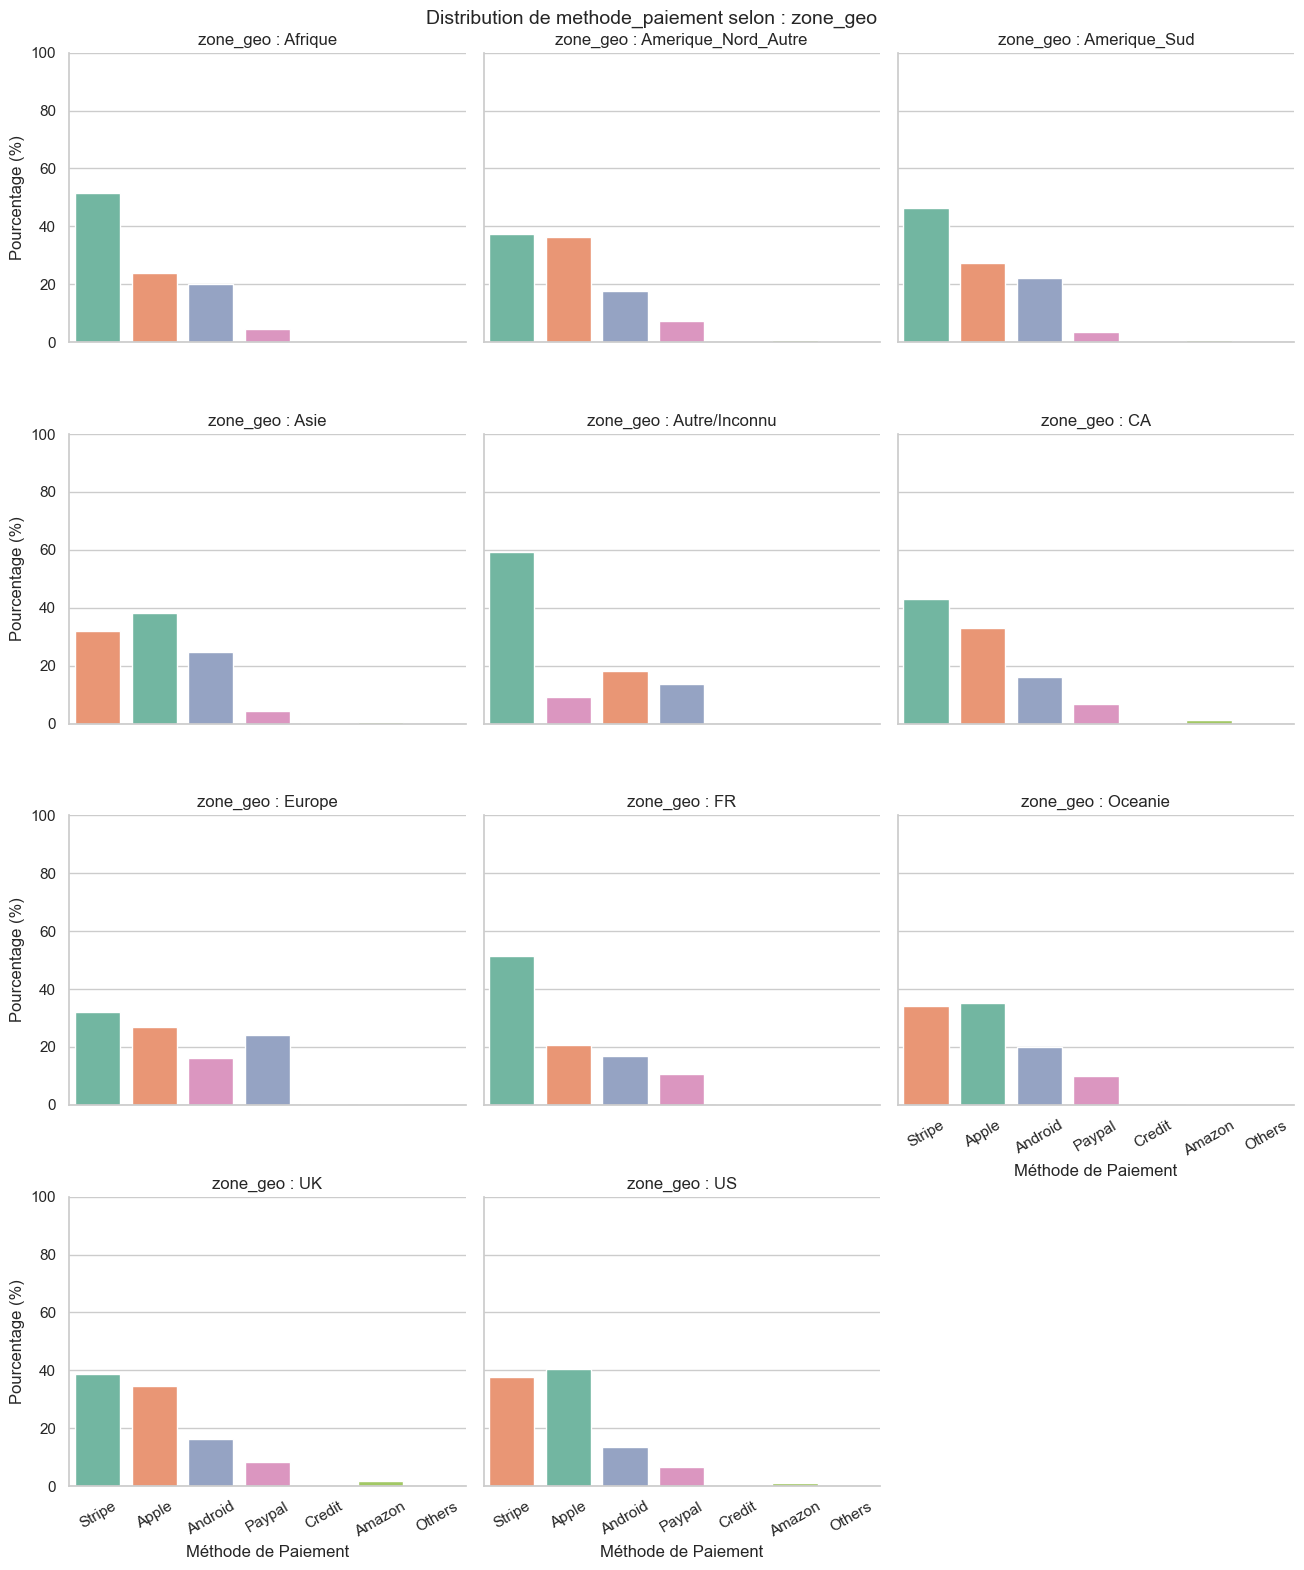

In [ ]:
# 1. Distribution globale de référence : methode_paiement
plt.figure(figsize=(6, 4))
dist_globale_paiement = data['methode_paiement'].value_counts(normalize=True) * 100
sns.barplot(x=dist_globale_paiement.index, y=dist_globale_paiement.values, palette='Blues_d')
plt.title('Distribution Globale : methode_paiement (Référence)')
plt.ylabel('Pourcentage (%)')
plt.xlabel('Méthode de Paiement')
plt.ylim(0, 100)
plt.tight_layout()
plt.show()

# 2. Liste des variables avec lesquelles croiser methode_paiement
liste_variables = [
    'avg_sessions_actifs_tr',
    'avg_songs_sessions_tr',
    'valeur_12M_tr',
    'statut_abonnement',
    'anciennete_client_tr',
    'zone_geo'
]

# 3. Boucle d'itération sur chaque variable
for var in liste_variables:
    # Calcul des proportions relatives de methode_paiement au sein de chaque modalité de 'var'
    df_prop = (
        data.groupby(var)['methode_paiement']
        .value_counts(normalize=True)
        .rename('pourcentage')
        .reset_index()
    )
    df_prop['pourcentage'] *= 100
    
    # Création de la grille de sous-graphiques (FacetGrid)
    g = sns.FacetGrid(df_prop, col=var, col_wrap=3, height=4, aspect=1.1)
    g.map_dataframe(sns.barplot, x='methode_paiement', y='pourcentage', palette='Set2')
    
    # Personnalisation visuelle
    g.set_axis_labels('Méthode de Paiement', 'Pourcentage (%)')
    g.set_titles(col_template=f'{var} : {{col_name}}')
    g.set(ylim=(0, 100))  # Échelle fixe à 100% pour observer les variations
    
    # Rotation des étiquettes
    for ax in g.axes.flat:
        ax.tick_params(axis='x', rotation=30)
        
    g.fig.subplots_adjust(top=0.85)
    g.fig.suptitle(f'Distribution de methode_paiement selon : {var}', fontsize=14)
    plt.tight_layout()
    plt.show()

In [ ]:
### RECODAGE ###

# 1. Dictionnaire de remappage des modalités
dictionnaire_anciennete = {
    # Moins de 6 mois (~19.9%)
    '00_moins_1_mois': '01_Moins_de_6_mois',
    '01_1_mois': '01_Moins_de_6_mois',
    '02_2_mois': '01_Moins_de_6_mois',
    '03_3_mois': '01_Moins_de_6_mois',
    '04_4_mois': '01_Moins_de_6_mois',
    '05_5_mois': '01_Moins_de_6_mois',
    
    # 6 à 12 mois (~28.9%)
    '06_6_mois': '02_6_a_12_mois',
    '07_7a9_mois': '02_6_a_12_mois',
    '08_10a12_mois': '02_6_a_12_mois',
    
    # 1 à 2 ans (~18.5%)
    '09_13a15_mois': '03_1_a_2_ans',
    '10_16a18_mois': '03_1_a_2_ans',
    '11_19a21_mois': '03_1_a_2_ans',
    '12_22a24_mois': '03_1_a_2_ans',
    
    # 2 à 4 ans (~18.6%)
    '13_25a30_mois': '04_2_a_4_ans',
    '14_31a36_mois': '04_2_a_4_ans',
    '15_37a48_mois': '04_2_a_4_ans',
    
    # Plus de 4 ans (~14.1%)
    '16_49a60_mois': '05_Plus_de_4_ans',
    '17_61a84_mois': '05_Plus_de_4_ans',
    '18_85a120_mois': '05_Plus_de_4_ans',
    '19_121_mois_et_plus': '05_Plus_de_4_ans'
}

# 2. Application du regroupement dans le DataFrame
data['anciennete_client_rec'] = data['anciennete_client_tr'].map(dictionnaire_anciennete)

# 3. Vérification des nouvelles fréquences et pourcentages
distribution_rec = pd.DataFrame({
    'Fréquence': data['anciennete_client_rec'].value_counts(),
    'Pourcentage (%)': (data['anciennete_client_rec'].value_counts(normalize=True) * 100).round(2)
})

print(distribution_rec)

                       Fréquence  Pourcentage (%)
anciennete_client_rec                            
02_6_a_12_mois             98460            28.87
01_Moins_de_6_mois         67839            19.89
04_2_a_4_ans               63540            18.63
03_1_a_2_ans               62931            18.45
05_Plus_de_4_ans           48322            14.17


In [ ]:
# 1. Dictionnaire de remappage des modalités
dict_anciennete_abo = {
    # Moins de 3 mois (~20.47%)
    '00_moins_1_mois': '01_Moins_de_3_mois',
    '01_1_mois': '01_Moins_de_3_mois',
    '02_2_mois': '01_Moins_de_3_mois',
    
    # 3 à 5 mois (~15.45%)
    '03_3_mois': '02_3_a_5_mois',
    '04_4_mois': '02_3_a_5_mois',
    '05_5_mois': '02_3_a_5_mois',
    
    # 6 à 12 mois (~38.67%)
    '06_6_mois': '03_6_a_12_mois',
    '07_7a9_mois': '03_6_a_12_mois',
    '08_10a12_mois': '03_6_a_12_mois',
    
    # 1 à 2 ans (~13.31%)
    '09_13a15_mois': '04_1_a_2_ans',
    '10_16a18_mois': '04_1_a_2_ans',
    '11_19a21_mois': '04_1_a_2_ans',
    '12_22a24_mois': '04_1_a_2_ans',
    
    # Plus de 2 ans (~12.11%)
    '13_25a30_mois': '05_Plus_de_2_ans',
    '14_31a36_mois': '05_Plus_de_2_ans',
    '15_37a48_mois': '05_Plus_de_2_ans',
    '16_49a60_mois': '05_Plus_de_2_ans',
    '17_61a84_mois': '05_Plus_de_2_ans',
    '18_85a120_mois': '05_Plus_de_2_ans',
    '19_121_mois_et_plus': '05_Plus_de_2_ans'
}

# 2. Application du regroupement
data['anciennete_abonnement_rec'] = data['anciennete_abonnement_tr'].map(dict_anciennete_abo)

# 3. Vérification des nouvelles fréquences et pourcentages
distribution_abo_rec = pd.DataFrame({
    'Fréquence': data['anciennete_abonnement_rec'].value_counts(),
    'Pourcentage (%)': (data['anciennete_abonnement_rec'].value_counts(normalize=True) * 100).round(2)
})

print(distribution_abo_rec)

                           Fréquence  Pourcentage (%)
anciennete_abonnement_rec                            
03_6_a_12_mois                131874            38.66
01_Moins_de_3_mois             69795            20.46
02_3_a_5_mois                  52697            15.45
04_1_a_2_ans                   45378            13.30
05_Plus_de_2_ans               41348            12.12


In [ ]:
# 1. Dictionnaire de remappage selon les spécifications métier
dict_methode_paiement = {
    # Regroupement Web / Paiements directs (Règle métier : Stripe et Paypal sont équivalents)
    'Stripe': 'web_et_direct',
    'Paypal': 'web_et_direct',
    
    # Regroupement Mobile / Application Store (Apple et Android regroupés sous 'telephone')
    'Apple': 'telephone',
    'Android': 'telephone',
    
    # Conservation des méthodes minoritaires séparées selon la demande
    'Amazon': 'Amazon',
    'Credit': 'Credit',
    'Others': 'Others' # Ligne unique à supprimer ultérieurement dans le nettoyage
}

# 2. Application de la transformation dans 'data'
data['methode_paiement_rec'] = data['methode_paiement'].map(dict_methode_paiement)

# 3. Vérification de la distribution
distribution_paiement = pd.DataFrame({
    'Fréquence': data['methode_paiement_rec'].value_counts(),
    'Pourcentage (%)': (data['methode_paiement_rec'].value_counts(normalize=True) * 100).round(2)
})

print("=== Distribution de methode_paiement_rec ===")
print(distribution_paiement)

=== Distribution de methode_paiement_rec ===
                      Fréquence  Pourcentage (%)
methode_paiement_rec                            
web_et_direct            172829            50.67
telephone                164814            48.32
Amazon                     2846             0.83
Credit                      602             0.18
Others                        1             0.00


In [ ]:
# 1. Dictionnaire de remappage pour la valeur financière sur 12 mois
dict_valeur_12M = {
    # Moins de 15 (~37.71%)
    '00_moins_10': '01_Moins_de_15',
    '01_10a15': '01_Moins_de_15',
    
    # 15 à 30 (~14.41%)
    '02_15a20': '02_15_a_30',
    '03_20a25': '02_15_a_30',
    '04_25a30': '02_15_a_30',
    
    # 30 à 50 (~13.38%)
    '05_30a40': '03_30_a_50',
    '06_40a50': '03_30_a_50',
    
    # 50 à 90 (~25.25%)
    '07_50a60': '04_50_a_90',
    '08_60a70': '04_50_a_90',
    '09_70a90': '04_50_a_90',
    
    # Plus de 90 (~9.26%)
    '10_90a110': '05_Plus_de_90',
    '11_110_et_plus': '05_Plus_de_90'
}

# 2. Application de la transformation dans 'data'
data['valeur_12M_rec'] = data['valeur_12M_tr'].map(dict_valeur_12M)

# 3. Vérification de la nouvelle distribution
distribution_valeur = pd.DataFrame({
    'Fréquence': data['valeur_12M_rec'].value_counts(),
    'Pourcentage (%)': (data['valeur_12M_rec'].value_counts(normalize=True) * 100).round(2)
})

print("=== Distribution de valeur_12M_rec ===")
print(distribution_valeur)

=== Distribution de valeur_12M_rec ===
                Fréquence  Pourcentage (%)
valeur_12M_rec                            
01_Moins_de_15     128630            37.71
04_50_a_90          86115            25.25
02_15_a_30          49154            14.41
03_30_a_50          45618            13.37
05_Plus_de_90       31575             9.26


In [ ]:
# 1. Dictionnaire de remappage pour le nombre moyen de sessions
dict_avg_sessions = {
    # Inactifs (~11.94%)
    '00_pas_de_session': '00_Inactif',
    
    # Usage faible (~42.28%)
    '01_moins_1': '01_Faible_1_a_2',
    '02_1a2': '01_Faible_1_a_2',
    
    # Usage moyen (~22.28%)
    '03_2a3': '02_Moyen_2_a_4',
    '04_3a4': '02_Moyen_2_a_4',
    
    # Usage élevé (~13.81%)
    '05_4a5': '03_Eleve_4_a_8',
    '06_5a6': '03_Eleve_4_a_8',
    '07_6a8': '03_Eleve_4_a_8',
    
    # Très forts utilisateurs / Power users (~9.69%)
    '08_8a10': '04_Tres_eleve_8_et_plus',
    '09_10a15': '04_Tres_eleve_8_et_plus',
    '10_15a20': '04_Tres_eleve_8_et_plus',
    '11_20a30': '04_Tres_eleve_8_et_plus',
    '12_30a50': '04_Tres_eleve_8_et_plus',
    '13_50_et_plus': '04_Tres_eleve_8_et_plus'
}

# 2. Application du regroupement dans 'data'
data['avg_sessions_actifs_rec'] = data['avg_sessions_actifs_tr'].map(dict_avg_sessions)

# 3. Vérification de la nouvelle distribution
distribution_sessions = pd.DataFrame({
    'Fréquence': data['avg_sessions_actifs_rec'].value_counts(),
    'Pourcentage (%)': (data['avg_sessions_actifs_rec'].value_counts(normalize=True) * 100).round(2)
})

print("=== Distribution de avg_sessions_actifs_rec ===")
print(distribution_sessions)

=== Distribution de avg_sessions_actifs_rec ===
                         Fréquence  Pourcentage (%)
avg_sessions_actifs_rec                            
01_Faible_1_a_2             144215            42.28
02_Moyen_2_a_4               75968            22.27
03_Eleve_4_a_8               47134            13.82
00_Inactif                   40716            11.94
04_Tres_eleve_8_et_plus      33059             9.69


In [ ]:
# 1. Dictionnaire de remappage pour le nombre moyen de chansons par session
dict_avg_songs = {
    # Inactifs (~11.94%)
    '00_pas_de_session': '00_Inactif',
    
    # Écoute faible : 1 à 5 titres (~28.44%)
    '01_1a2': '01_Faible_1_a_5',
    '02_2a3': '01_Faible_1_a_5',
    '03_3a4': '01_Faible_1_a_5',
    '04_4a5': '01_Faible_1_a_5',
    
    # Écoute moyenne : 5 à 10 titres (~23.72%)
    '05_5a6': '02_Moyen_5_a_10',
    '06_6a8': '02_Moyen_5_a_10',
    '07_8a10': '02_Moyen_5_a_10',
    
    # Écoute élevée : 10 à 20 titres (~22.51%)
    '08_10a15': '03_Eleve_10_a_20',
    '09_15a20': '03_Eleve_10_a_20',
    
    # Écoute très élevée : 20 titres et plus (~13.38%)
    '10_20a30': '04_Tres_eleve_20_et_plus',
    '11_30a50': '04_Tres_eleve_20_et_plus',
    '12_50_et_plus': '04_Tres_eleve_20_et_plus'
}

# 2. Application du regroupement dans 'data'
data['avg_songs_sessions_rec'] = data['avg_songs_sessions_tr'].map(dict_avg_songs)

# 3. Vérification de la nouvelle distribution
distribution_songs = pd.DataFrame({
    'Fréquence': data['avg_songs_sessions_rec'].value_counts(),
    'Pourcentage (%)': (data['avg_songs_sessions_rec'].value_counts(normalize=True) * 100).round(2)
})

print("=== Distribution de avg_songs_sessions_rec ===")
print(distribution_songs)

=== Distribution de avg_songs_sessions_rec ===
                          Fréquence  Pourcentage (%)
avg_songs_sessions_rec                              
01_Faible_1_a_5               97035            28.45
02_Moyen_5_a_10               80920            23.72
03_Eleve_10_a_20              76782            22.51
04_Tres_eleve_20_et_plus      45639            13.38
00_Inactif                    40716            11.94


In [ ]:
# 1. Dictionnaire de remappage géographique
dict_zone_geo = {
    # Marché américain principal
    'US': '01_US',
    
    # Bloc Europe (Europe, France et Royaume-Uni : ~45.73%)
    'Europe': '02_Europe',
    'FR': '02_Europe',
    'UK': '02_Europe',
    
    # Canada (~7.04%)
    'CA': '03_CA',
    
    # Regroupement des zones < 3% (~5.94%)
    'Oceanie': '04_Reste_du_Monde',
    'Asie': '04_Reste_du_Monde',
    'Amerique_Nord_Autre': '04_Reste_du_Monde',
    'Amerique_Sud': '04_Reste_du_Monde',
    'Afrique': '04_Reste_du_Monde',
    'Autre/Inconnu': '04_Reste_du_Monde'
}

# 2. Application de la transformation
data['zone_geo_rec'] = data['zone_geo'].map(dict_zone_geo)

# 3. Vérification de la nouvelle distribution
distribution_geo = pd.DataFrame({
    'Fréquence': data['zone_geo_rec'].value_counts(),
    'Pourcentage (%)': (data['zone_geo_rec'].value_counts(normalize=True) * 100).round(2)
})

print("=== Distribution de zone_geo_rec ===")
print(distribution_geo)

=== Distribution de zone_geo_rec ===
                   Fréquence  Pourcentage (%)
zone_geo_rec                                 
02_Europe             155980            45.73
01_US                 140842            41.29
03_CA                  23999             7.04
04_Reste_du_Monde      20271             5.94



=== statut_abonnement ===


C:\Users\SebastianAraya\AppData\Local\Temp\ipykernel_26748\951469075.py:28: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  col for col in data_clean.select_dtypes(include=['object', 'category']).columns


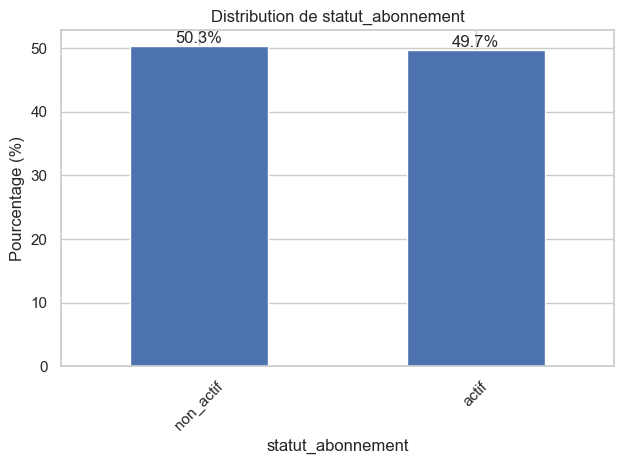


=== type_client ===


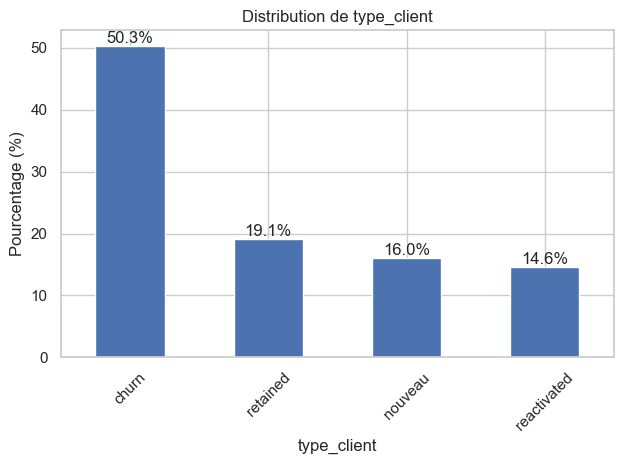


=== ratio_fidelite_tr ===


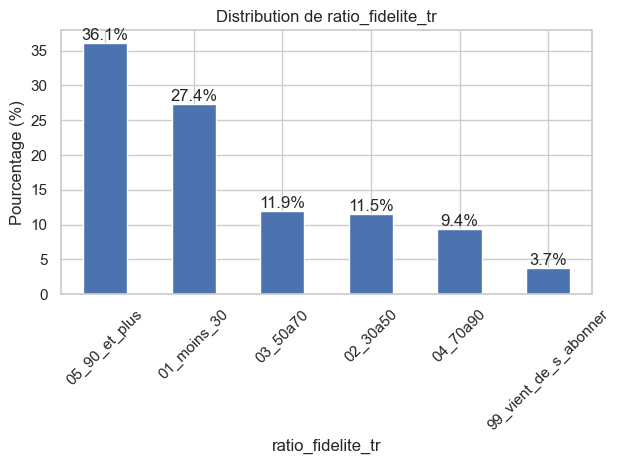


=== utilise_remote ===


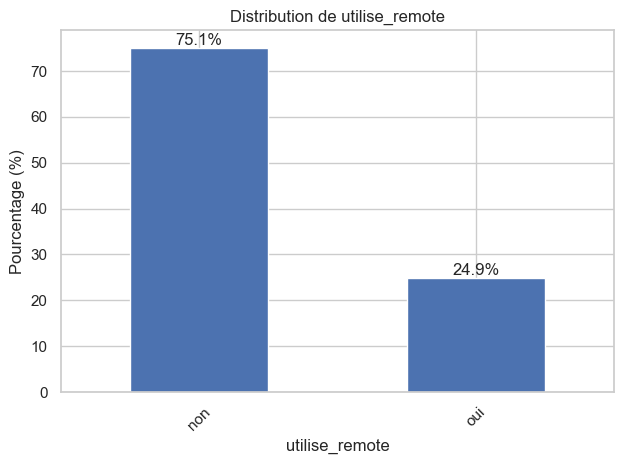


=== contactable ===


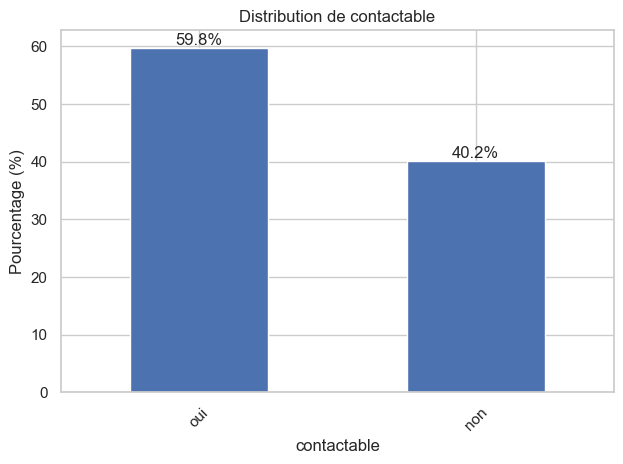


=== anciennete_client_rec ===


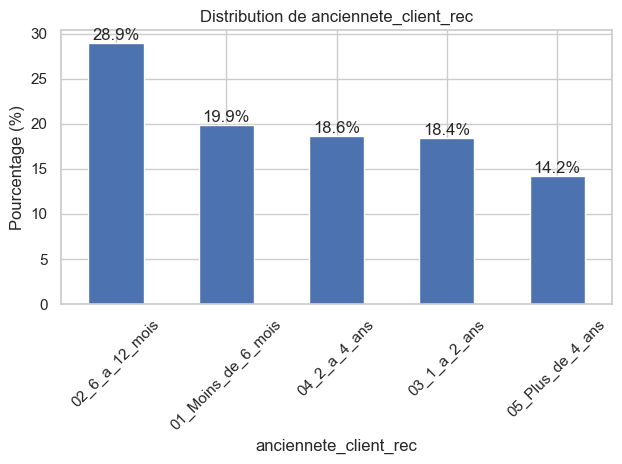


=== anciennete_abonnement_rec ===


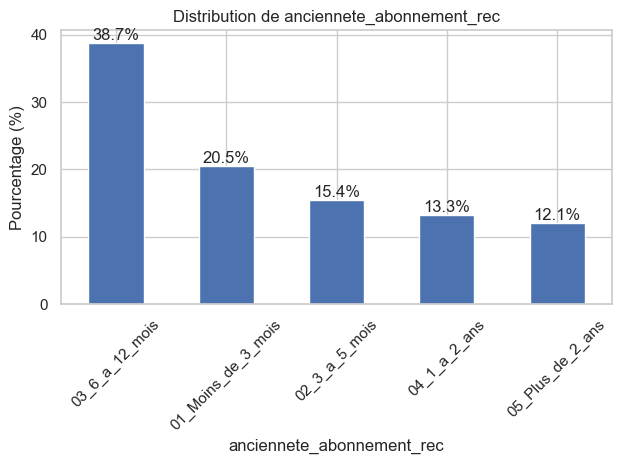


=== methode_paiement_rec ===


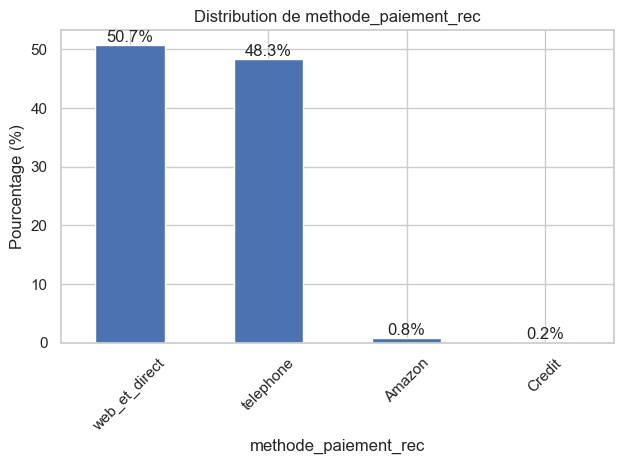


=== valeur_12M_rec ===


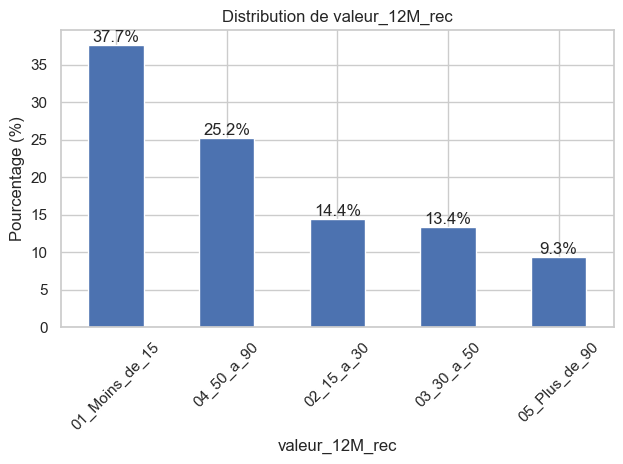


=== avg_sessions_actifs_rec ===


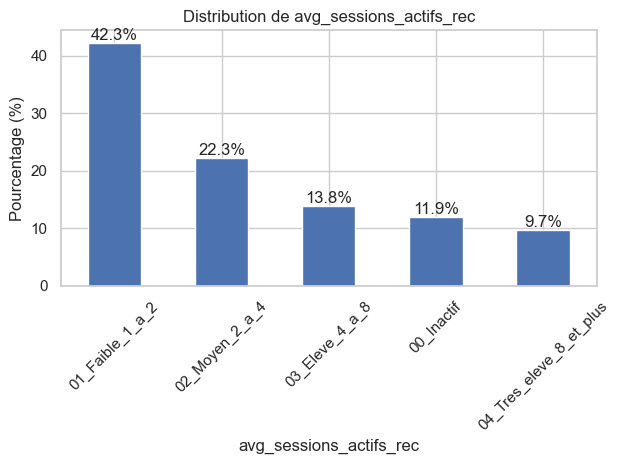


=== avg_songs_sessions_rec ===


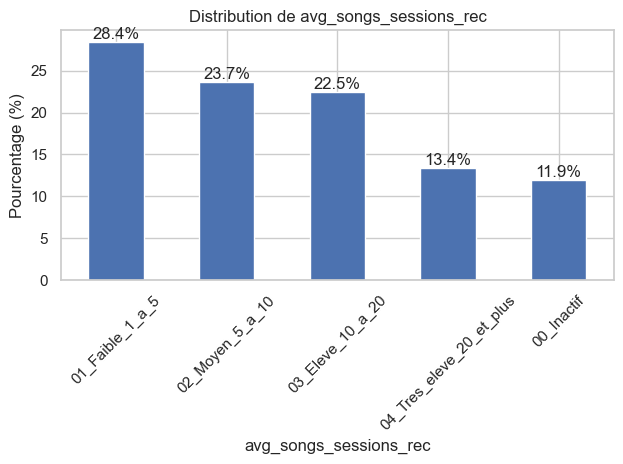


=== zone_geo_rec ===


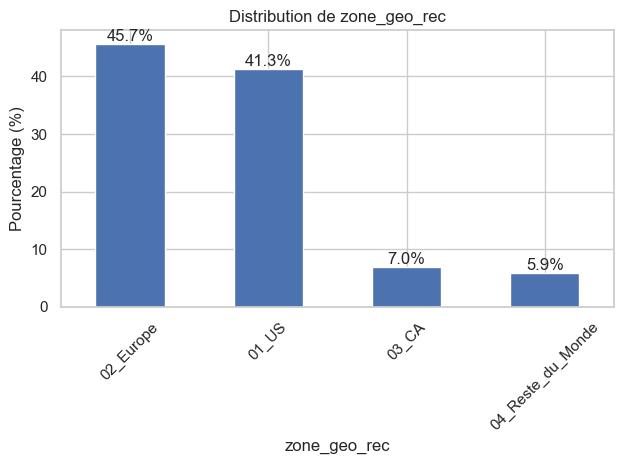

In [33]:
# 1. Liste des variables d'origine à supprimer :
# - Variables ayant été recodées en version '_rec'
# - Variables sans pouvoir explicatif (modalité quasi-unique / variance nulle)
vars_a_supprimer = [
    # Variables recodées
    'id_anonyme',
    'anciennete_client_tr',
    'anciennete_abonnement_tr',
    'methode_paiement',
    'valeur_12M_tr',
    'avg_sessions_actifs_tr',
    'avg_songs_sessions_tr',
    'zone_geo',
    
    # Variables supprimées car quasi-constantes (une seule modalité dominante, aucun pouvoir explicatif)
    'type_very_first_abo',
    'type_first_abo_last_streak'
]

# 2. Suppression de la ligne unique 'Others' avant la création de data_clean
data = data[data['methode_paiement'] != 'Others'].copy()

# 3. Création du DataFrame nettoyé
data_clean = data.drop(columns=vars_a_supprimer)

# 4. Identification automatique des variables qualitatives restantes
var_quali = [
    col for col in data_clean.select_dtypes(include=['object', 'category']).columns 
    if col != 'id_anonyme'
]

# 5. Graphiques de distribution en pourcentage
for var in var_quali:
    print(f"\n=== {var} ===")
    pcts = (data_clean[var].value_counts(normalize=True) * 100).round(1)
    
    ax = pcts.plot(kind='bar')
    plt.title(f'Distribution de {var}')
    plt.xlabel(var)
    plt.ylabel('Pourcentage (%)')
    plt.xticks(rotation=45)
    
    for i, pct in enumerate(pcts):
        ax.text(i, pct, f'{pct}%', ha='center', va='bottom')
    
    plt.tight_layout()
    plt.show()

In [34]:
data_clean.head()

,statut_abonnement,type_client,ratio_fidelite_tr,nb_abo_periode,utilise_remote,contactable,anciennete_client_rec,anciennete_abonnement_rec,methode_paiement_rec,valeur_12M_rec,avg_sessions_actifs_rec,avg_songs_sessions_rec,zone_geo_rec
0,actif,nouveau,99_vient_de_s_abonner,1,non,oui,01_Moins_de_6_mois,01_Moins_de_3_mois,telephone,01_Moins_de_15,01_Faible_1_a_2,01_Faible_1_a_5,01_US
1,actif,nouveau,99_vient_de_s_abonner,1,non,oui,01_Moins_de_6_mois,01_Moins_de_3_mois,telephone,01_Moins_de_15,02_Moyen_2_a_4,01_Faible_1_a_5,02_Europe
2,actif,nouveau,99_vient_de_s_abonner,1,non,non,01_Moins_de_6_mois,01_Moins_de_3_mois,web_et_direct,01_Moins_de_15,02_Moyen_2_a_4,03_Eleve_10_a_20,02_Europe
3,actif,nouveau,99_vient_de_s_abonner,1,non,oui,01_Moins_de_6_mois,01_Moins_de_3_mois,web_et_direct,01_Moins_de_15,01_Faible_1_a_2,03_Eleve_10_a_20,03_CA
4,actif,nouveau,99_vient_de_s_abonner,1,non,oui,01_Moins_de_6_mois,01_Moins_de_3_mois,web_et_direct,01_Moins_de_15,00_Inactif,00_Inactif,02_Europe


ACM configurée sur un échantillon de 10000 individus et 12 variables.

=== Inertie expliquée par les axes factoriels ===
  Axe  Valeur Propre (Eigenvalue)  Inertie Expliquée (%)  Inertie Cumulée (%)
Axe 1                        0.32                  10.32                10.32
Axe 2                        0.24                   7.88                18.20
Axe 3                        0.18                   5.72                23.91
Axe 4                        0.14                   4.70                28.61
Axe 5                        0.14                   4.46                33.07

Nombre total de modalités (K) : 49
Seuil de contribution moyenne : 2.04 %

=== Modalités retenues pour l'interprétation (Contribution > Moyenne) ===
                                               Coord_Axe1  Contrib_Axe1 (%)  \
type_client__retained                                1.58             12.67   
statut_abonnement__actif                             0.81              8.52   
statut_abonnement__non_a

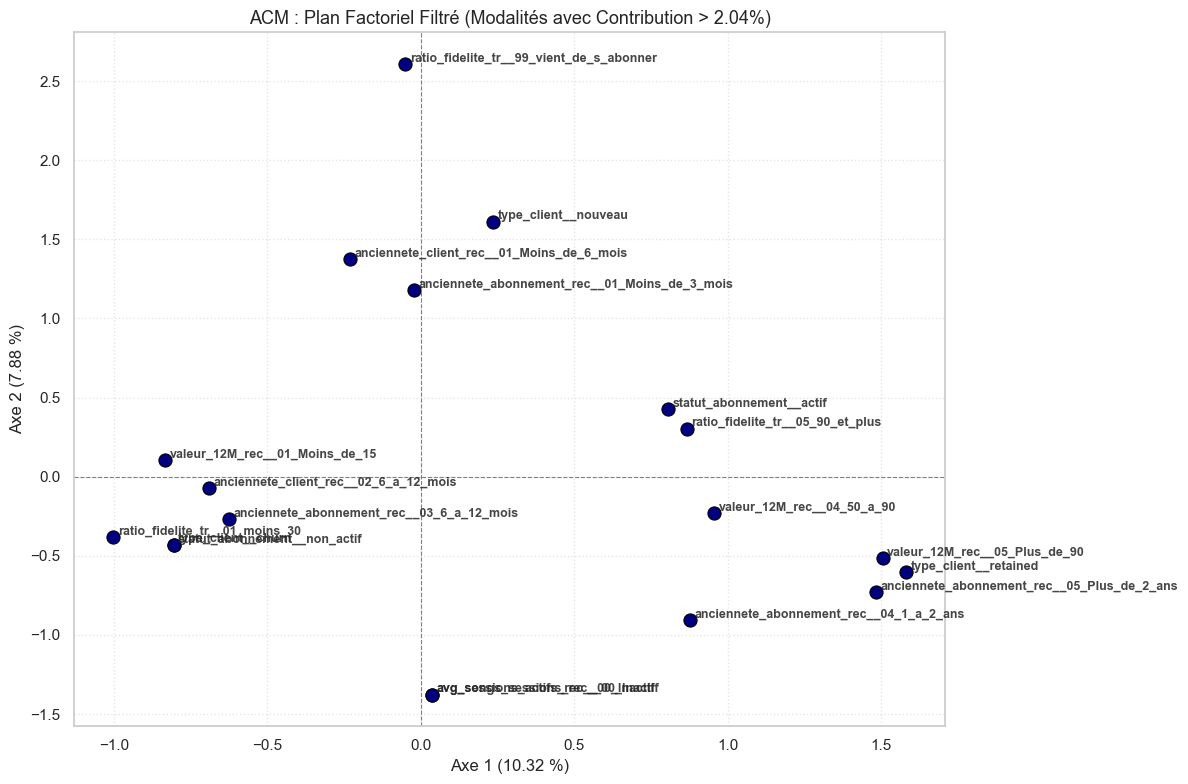

In [ ]:
# ===== ACM =====

# 1. Échantillonnage aléatoire pour l'ACM
TAILLE_ECHANTILLON = 10000
SEED = 42

vars_acm = [
    col for col in data_clean.select_dtypes(include=['object', 'category']).columns 
    if col != 'id_anonyme'
]

df_acm = data_clean[vars_acm].sample(n=min(len(data_clean), TAILLE_ECHANTILLON), random_state=SEED)

print(f"ACM configurée sur un échantillon de {len(df_acm)} individus et {len(vars_acm)} variables.")

# 2. Ajustement du modèle ACM
mca = prince.MCA(
    n_components=5,
    n_iter=10,
    copy=True,
    check_input=True,
    engine='sklearn',
    random_state=SEED
)

mca = mca.fit(df_acm)

# 3. Calcul et affichage de l'Inertie / Variance expliquée par chaque axe
eigenvalues = mca.eigenvalues_
percentage_of_variance = mca.percentage_of_variance_  # Déjà exprimé en % dans prince récent

df_inertie = pd.DataFrame({
    'Axe': [f'Axe {i+1}' for i in range(len(eigenvalues))],
    'Valeur Propre (Eigenvalue)': eigenvalues,
    'Inertie Expliquée (%)': percentage_of_variance,
    'Inertie Cumulée (%)': np.cumsum(percentage_of_variance)
})

print("\n=== Inertie expliquée par les axes factoriels ===")
print(df_inertie.round(2).to_string(index=False))

# 4. Calcul des contributions et du seuil moyen
contribs = mca.column_contributions_

# Conversion en pourcentage si l'échelle est en proportion (0 à 1)
if contribs.values.max() <= 1.0:
    contribs = contribs * 100

K = len(contribs)  # Nombre total de modalités
seuil_moyen = 100 / K

print(f"\nNombre total de modalités (K) : {K}")
print(f"Seuil de contribution moyenne : {seuil_moyen:.2f} %\n")

# 5. Filtrage : Masque pour conserver les modalités avec contribution > moyenne sur l'Axe 1 OU l'Axe 2
mask_plan1_2 = (contribs[0] > seuil_moyen) | (contribs[1] > seuil_moyen)

coords_totales = mca.column_coordinates(df_acm)
coords_filtrees = coords_totales[mask_plan1_2]
contribs_filtrees = contribs[mask_plan1_2]

# Tableau récapitulatif pour l'interprétation
df_interpretation = pd.DataFrame({
    'Coord_Axe1': coords_filtrees[0],
    'Contrib_Axe1 (%)': contribs_filtrees[0],
    'Coord_Axe2': coords_filtrees[1],
    'Contrib_Axe2 (%)': contribs_filtrees[1]
}).sort_values(by='Contrib_Axe1 (%)', ascending=False)

print("=== Modalités retenues pour l'interprétation (Contribution > Moyenne) ===")
print(df_interpretation.round(2))

# 6. Visualisation du Plan Factoriel Filtré (Axe 1 vs Axe 2)
plt.figure(figsize=(12, 8))

sns.scatterplot(
    x=coords_filtrees[0], 
    y=coords_filtrees[1], 
    color='navy', 
    s=90, 
    edgecolor='black'
)

for modalite, coord in coords_filtrees.iterrows():
    plt.text(
        coord[0] + 0.015, 
        coord[1] + 0.015, 
        str(modalite), 
        fontsize=9, 
        fontweight='bold', 
        alpha=0.85
    )

plt.axhline(0, color='grey', linestyle='--', linewidth=0.8)
plt.axvline(0, color='grey', linestyle='--', linewidth=0.8)

plt.title(f'ACM : Plan Factoriel Filtré (Modalités avec Contribution > {seuil_moyen:.2f}%)', fontsize=13)
plt.xlabel(f'Axe 1 ({percentage_of_variance[0]:.2f} %)')
plt.ylabel(f'Axe 2 ({percentage_of_variance[1]:.2f} %)')
plt.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.show()